# Equal-Volume Cylindrical Shell Theta Baseline

This baseline uses centered cylindrical shell bands with equal shell volume.

Each shell is defined by successive outer boundaries:
- `R_i = R_max * (i / n_shells)^(1/3)`
- `Z_i = Z_max * (i / n_shells)^(1/3)`

The target is `inside_shell`, meaning an event lies inside shell band `i` and outside shell band `i-1`.


In [1]:
from __future__ import annotations

import json
import yaml
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "prepare_resum_data.py").exists() and (candidate / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find the XLZD repo root from the current working directory.")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

if str(REPO_ROOT / "src" / "run_cnp") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src" / "run_cnp"))
if str(REPO_ROOT / "src" / "run_mfgp") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src" / "run_mfgp"))

from cnp_clean_pipeline import load_runtime_config, predict_cnp, train_cnp
from mfgp_clean_pipeline import run_mfgp_transform_suite

PREP_CONFIG_PATH = REPO_ROOT / "xlzd_equal_volume_shell_theta" / "config" / "pipeline_config.json"
NOTEBOOK_CONFIG_PATH = REPO_ROOT / "xlzd_equal_volume_shell_theta" / "config" / "runtime_notebook_config.json"
CONFIG_PATH = REPO_ROOT / "xlzd_equal_volume_shell_theta" / "settings_equal_volume_shell_minibatch.yaml"
VALIDATION_CONFIG_PATH = REPO_ROOT / "xlzd_equal_volume_shell_theta" / "settings_equal_volume_shell_validation_minibatch.yaml"
DATASET_ROOT = REPO_ROOT / "outputs_equal_volume_shell_theta"

SEED = 42
STEPS_PER_EPOCH = 5000
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.0
REPR_DIM = 32
HIDDEN = 128
DROPOUT = 0.1
MONITOR_EVERY = 5000
MC_SAMPLES = 30
CHUNK_SIZE = 20000
GRID_POINTS = 60
RANDOM_STATE = 42
TARGET_TRANSFORMS = ["linear", "log_hf", "log_lf", "log_both"]


## 1. Choose Notebook Parameters

Edit these values here instead of changing the default JSON config.


In [2]:
NOTEBOOK_PARAMS = {
    "R_max": 1500.0,
    "Z_max": 2000.0,
    "n_shells": 100,
    "min_candidate_events": 1,
    "max_events_per_file": None,
    "lf_block_size": 20000,
    "hf_block_size": 100000,
    "validation_block_size": None,
    "negative_shells": 4,
    "scale_power": 1.0/3.0
}

pd.DataFrame({
    "parameter": list(NOTEBOOK_PARAMS.keys()),
    "value": list(NOTEBOOK_PARAMS.values()),
})


,parameter,value
0,R_max,1500.000000
1,Z_max,2000.000000
2,n_shells,100.000000
3,min_candidate_events,1.000000
4,max_events_per_file,NaN
5,lf_block_size,20000.000000
6,hf_block_size,100000.000000
7,validation_block_size,NaN
8,negative_shells,4.000000
9,scale_power,0.333333


## Parameter Guide

- `n_shells`: higher means thinner shells and more spatial resolution; lower means thicker shells and more events per shell.
- `min_candidate_events`: higher means only well-supported shells survive; lower means more inner/sparse shells are allowed, but they will be noisier.
- `lf_block_size`: higher means fewer LF files and fewer required shell assignments; lower means more LF files and more repeated shell assignments if shell diversity is limited.
- `hf_block_size`: higher means fewer HF training files; lower means more HF training files.
- `validation_block_size`: if `None`, validation uses the HF block size; lowering it creates more validation files.
- `R_max`, `Z_max`: set the outer cylindrical boundary family used to generate the equal-volume shell bands.

This notebook writes a temporary runtime config but always reuses the same dataset folder:
- `outputs_equal_volume_shell_theta`

So rerunning the prep command overwrites the previous equal-volume shell dataset instead of creating a new dataset tree each time.


## 2. Build A Runtime Config From Those Parameters


In [3]:
prep_config = json.loads(PREP_CONFIG_PATH.read_text())
prep_config["file_load"]["max_rows_per_file"] = NOTEBOOK_PARAMS["max_events_per_file"]
prep_config["shell"]["R_max"] = float(NOTEBOOK_PARAMS["R_max"])
prep_config["shell"]["Z_max"] = float(NOTEBOOK_PARAMS["Z_max"])
prep_config["shell"]["n_shells"] = int(NOTEBOOK_PARAMS["n_shells"])
prep_config["shell"]["min_candidate_events"] = int(NOTEBOOK_PARAMS["min_candidate_events"])
prep_config["sampling"]["lf_block_size"] = int(NOTEBOOK_PARAMS["lf_block_size"])
prep_config["sampling"]["hf_block_size"] = int(NOTEBOOK_PARAMS["hf_block_size"])
prep_config["sampling"]["validation_block_size"] = NOTEBOOK_PARAMS["validation_block_size"]
prep_config["shell"]["scale_power"] = float(NOTEBOOK_PARAMS["scale_power"])
prep_config["shell"]["negative_shells"] = int(NOTEBOOK_PARAMS["negative_shells"])

# Make sure the yamls have the correct shell geometry
for yaml_path in [CONFIG_PATH, VALIDATION_CONFIG_PATH]:
    yaml_config = yaml.safe_load(yaml_path.read_text())
    sim = yaml_config["simulation_settings"]

    sim["R_max"] = float(NOTEBOOK_PARAMS["R_max"])
    sim["Z_max"] = float(NOTEBOOK_PARAMS["Z_max"])
    sim["n_shells"] = int(NOTEBOOK_PARAMS["n_shells"])
    sim["scale_power"] = float(NOTEBOOK_PARAMS["scale_power"])
    sim["negative_shells"] = int(NOTEBOOK_PARAMS["negative_shells"])

    yaml_path.write_text(
        yaml.safe_dump(
            yaml_config,
            sort_keys=False,
        )
    )

NOTEBOOK_CONFIG_PATH.write_text(json.dumps(prep_config, indent=2))

runtime = load_runtime_config(CONFIG_PATH, seed=SEED)
validation_runtime = load_runtime_config(VALIDATION_CONFIG_PATH, seed=SEED)

summary = pd.DataFrame({
    "field": [
        "version",
        "dataset_root",
        "R_max",
        "Z_max",
        "n_shells",
        "min_candidate_events",
        "lf_block_size",
        "hf_block_size",
        "validation_block_size",
        "theta_headers",
        "phi_headers",
        "target_headers",
        "scale_power",
        "negative_shells",
    ],
    "value": [
        runtime.version,
        str(DATASET_ROOT),
        prep_config["shell"].get("R_max"),
        prep_config["shell"].get("Z_max"),
        prep_config["shell"].get("n_shells"),
        prep_config["shell"].get("min_candidate_events"),
        prep_config["sampling"].get("lf_block_size"),
        prep_config["sampling"].get("hf_block_size"),
        prep_config["sampling"].get("validation_block_size"),
        prep_config["shell"].get("scale_power"),
        prep_config["shell"].get("negative_shells"),
        ", ".join(runtime.theta_headers),
        ", ".join(runtime.phi_headers),
        ", ".join(runtime.target_headers),
    ],
})
summary


,field,value
0,version,xlzd_equal_volume_shell_v1_minibatch
1,dataset_root,/home/liuser/pknauss/XLZD/outputs_equal_volume...
2,R_max,1500.0
3,Z_max,2000.0
4,n_shells,100
5,min_candidate_events,1
6,lf_block_size,20000
7,hf_block_size,100000
8,validation_block_size,None
9,theta_headers,0.333333


## 3. Prepare The Equal-Volume Shell Dataset

Run this from the repo root before training if the dataset has not been built yet.

If you want more inner-shell candidates, lower `min_candidate_events` first. If you want fewer repeated shell assignments, increase `lf_block_size`.

This prep step now clears and rebuilds `outputs_equal_volume_shell_theta`, so changing notebook parameters refreshes the same dataset instead of leaving old files behind.


In [4]:
import subprocess

cmd = [
    sys.executable,
    "xlzd_equal_volume_shell_theta/prepare_equal_volume_shell_data.py",
    "--config",
    str(NOTEBOOK_CONFIG_PATH.relative_to(REPO_ROOT)),
]

print("$ " + " ".join(cmd))
subprocess.run(cmd, cwd=REPO_ROOT, check=True)

$ /home/liuser/miniconda3/bin/python xlzd_equal_volume_shell_theta/prepare_equal_volume_shell_data.py --config xlzd_equal_volume_shell_theta/config/runtime_notebook_config.json

[07:09:37] Loading and normalizing raw event files


Loading event files: 100%|██████████| 7/7 [00:04<00:00,  1.59it/s]


[done in 5.08s] Loaded 7 files

[07:09:42] Computing centered coordinates
[done in 3.74s] Computed z_from_center using z_center=1982.48

[07:09:46] Splitting raw events into disjoint LF/HF/validation pools
[done in 2.16s] Pool split complete

[07:09:48] Splitting pools into equal-size event blocks
[done in 0.00s] Pool block split complete

[07:09:48] Building equal-volume shell candidates from LF support
[done in 0.06s] Built 88 valid shell candidates

[07:09:48] Clearing existing dataset directory: outputs_equal_volume_shell_theta
[done in 0.02s] Removed previous equal-volume shell dataset

[07:09:48] Writing LF Training event-shell pair H5 blocks
[done in 83.59s] 53 LF Training block written

[07:11:12] Writing HF Training event-shell pair H5 blocks
[done in 171.43s] 21 HF Training block written

[07:14:03] Writing HF Validation event-shell pair H5 blocks
[done in 170.68s] 21 HF Validation block written

[07:16:54] Writing pool tables and manifests
[done in 151.45s] Output files writ

CompletedProcess(args=['/home/liuser/miniconda3/bin/python', 'xlzd_equal_volume_shell_theta/prepare_equal_volume_shell_data.py', '--config', 'xlzd_equal_volume_shell_theta/config/runtime_notebook_config.json'], returncode=0)

## 4. Train The CNP


[info] Random mini-batch mode is enabled. Each epoch uses 5000 sampled steps.
2026-06-08 07:19:26 Iteration: 0/0, train BCE: 0.8481, val BCE: 0.8015


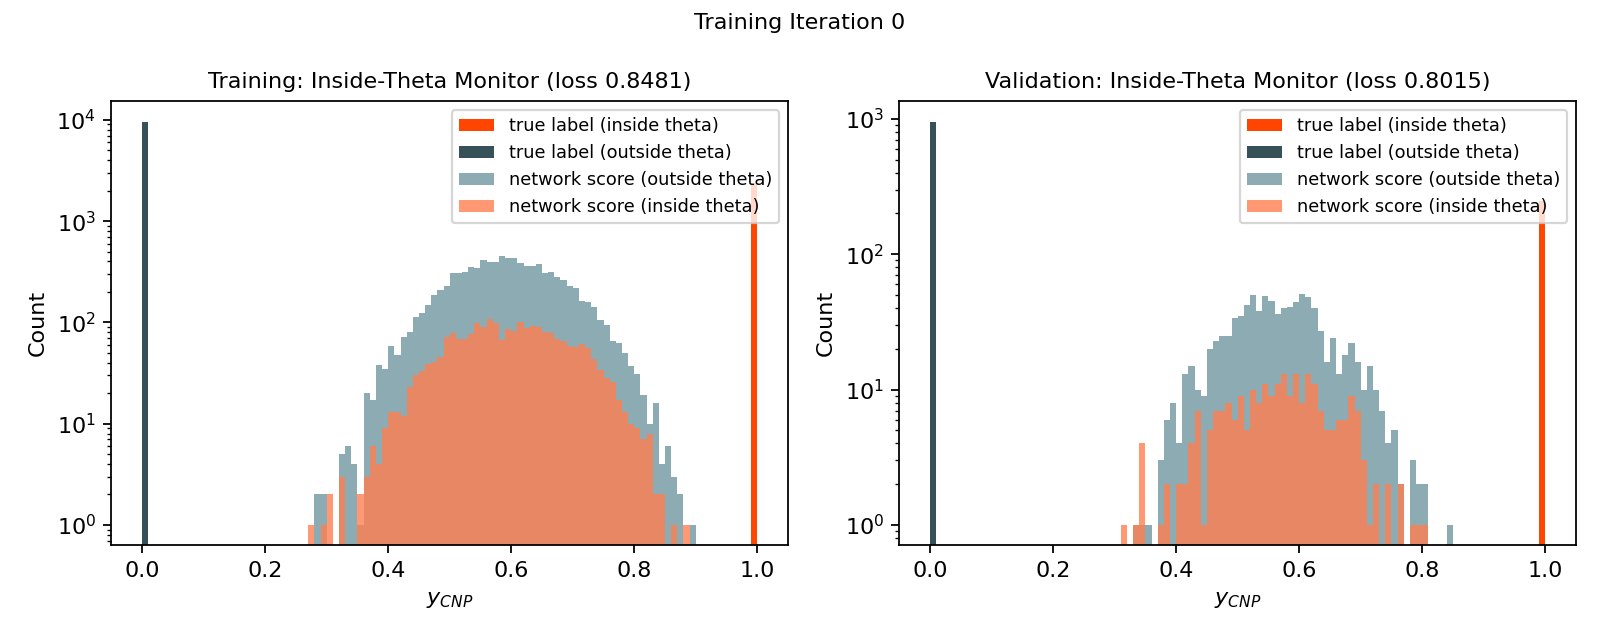

Epoch 1/15 | step=4999 | epoch_steps=5000 | train_bce=0.28746 | val_bce=0.30512
2026-06-08 07:19:53 Iteration: 1/5000, train BCE: 0.2929, val BCE: 0.3134


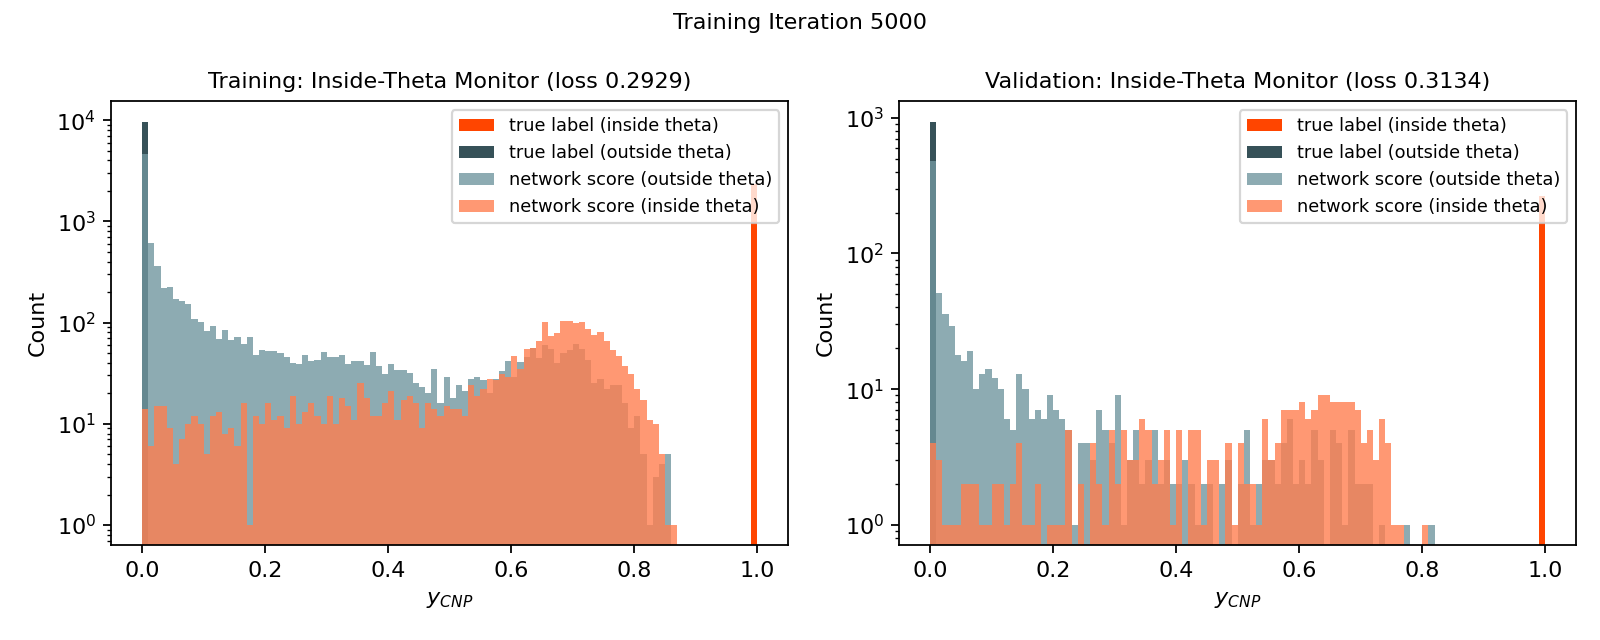

Epoch 2/15 | step=9999 | epoch_steps=5000 | train_bce=0.28926 | val_bce=0.28431
2026-06-08 07:20:18 Iteration: 2/10000, train BCE: 0.3031, val BCE: 0.3388


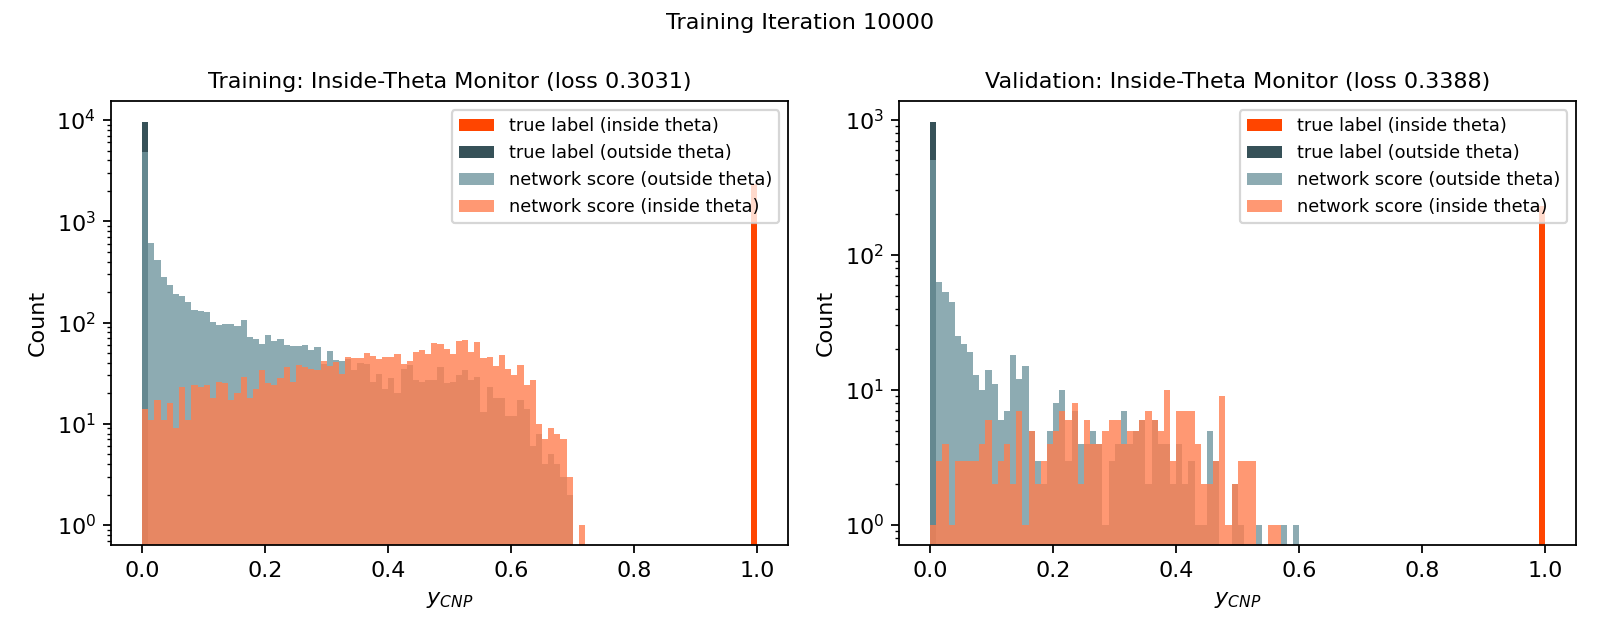

Epoch 3/15 | step=14999 | epoch_steps=5000 | train_bce=0.28661 | val_bce=0.32239
2026-06-08 07:20:45 Iteration: 3/15000, train BCE: 0.2880, val BCE: 0.2811


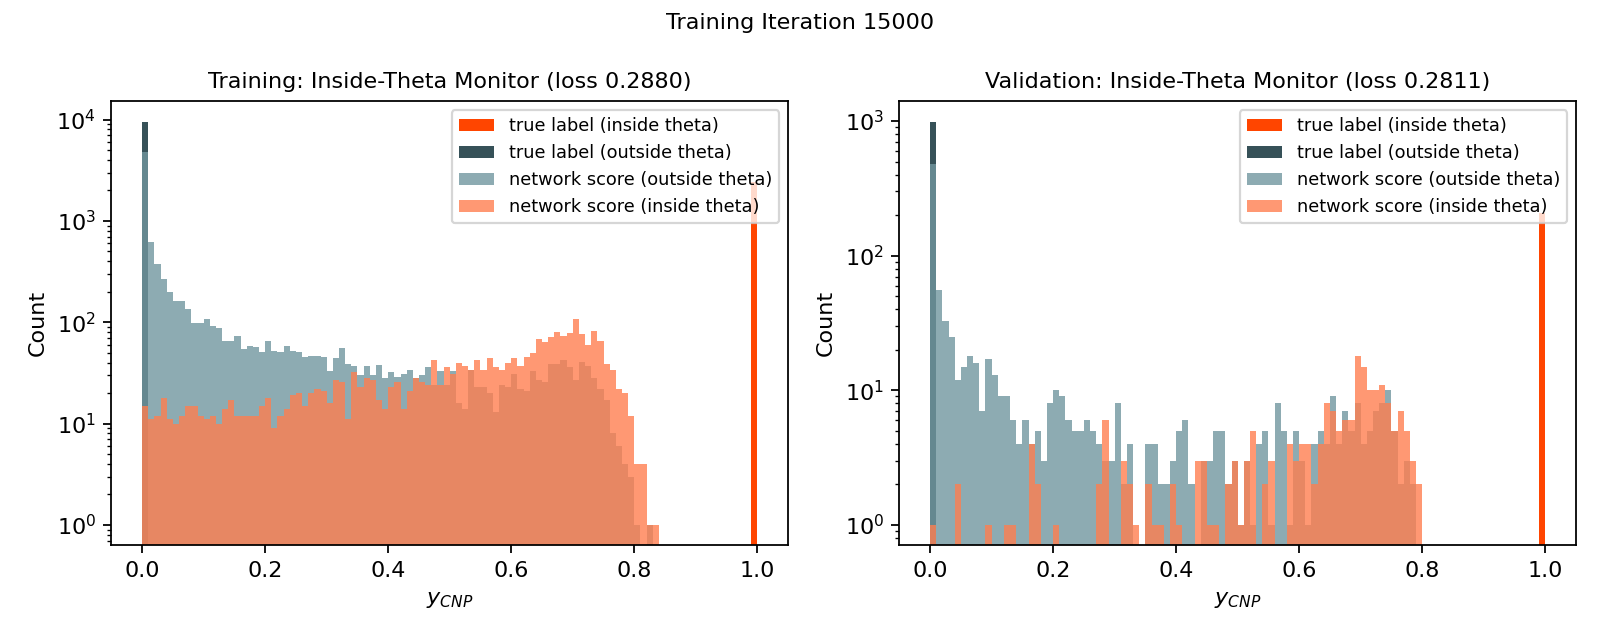

Epoch 4/15 | step=19999 | epoch_steps=5000 | train_bce=0.27756 | val_bce=0.26586
2026-06-08 07:21:13 Iteration: 4/20000, train BCE: 0.2866, val BCE: 0.2834


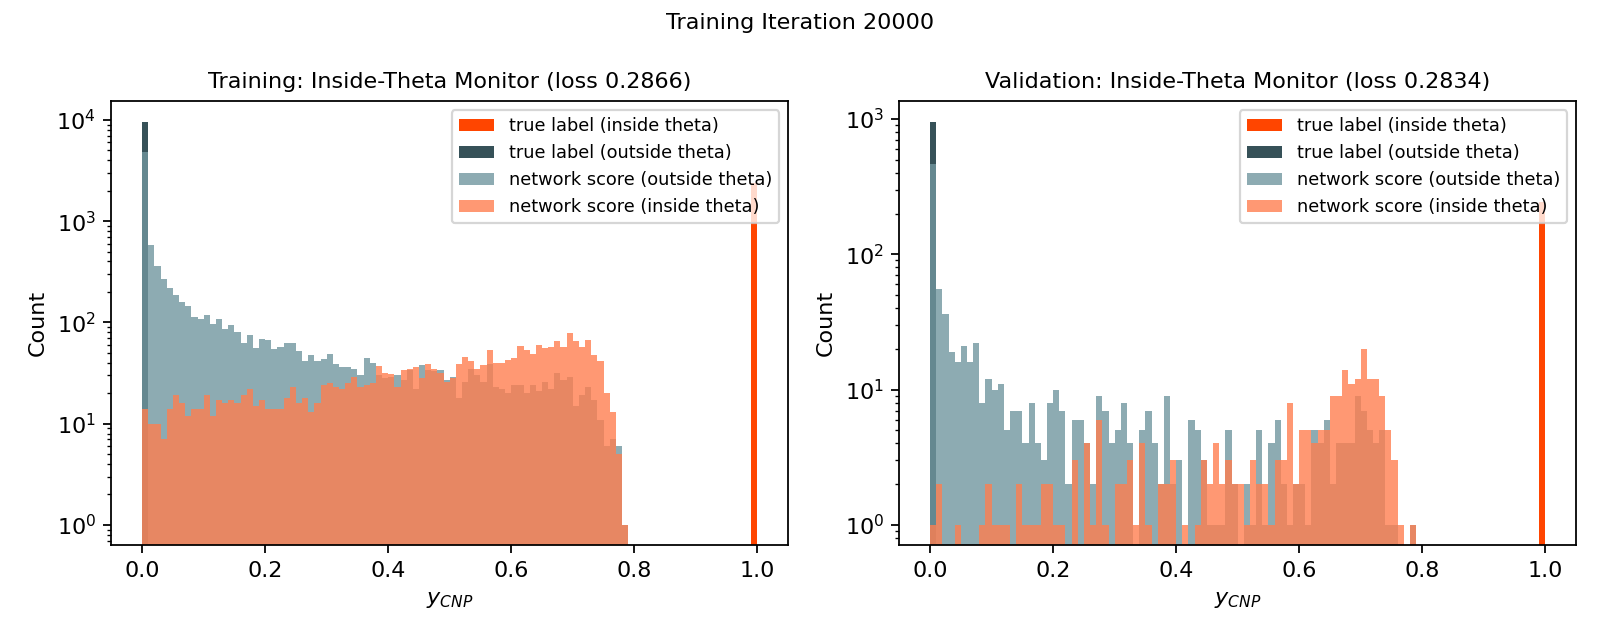

Epoch 5/15 | step=24999 | epoch_steps=5000 | train_bce=0.28778 | val_bce=0.31338
2026-06-08 07:21:39 Iteration: 5/25000, train BCE: 0.2941, val BCE: 0.3012


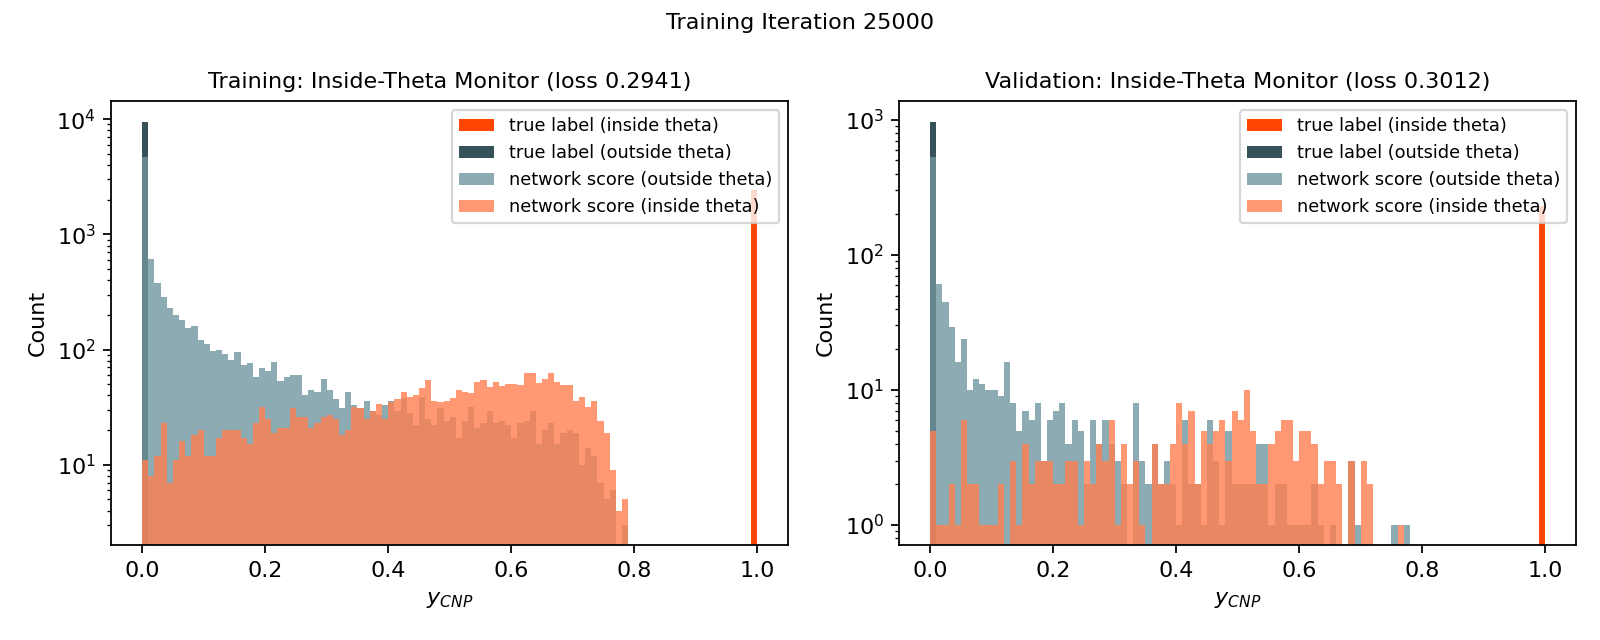

Epoch 6/15 | step=29999 | epoch_steps=5000 | train_bce=0.30139 | val_bce=0.28274
2026-06-08 07:22:07 Iteration: 6/30000, train BCE: 0.2797, val BCE: 0.2571


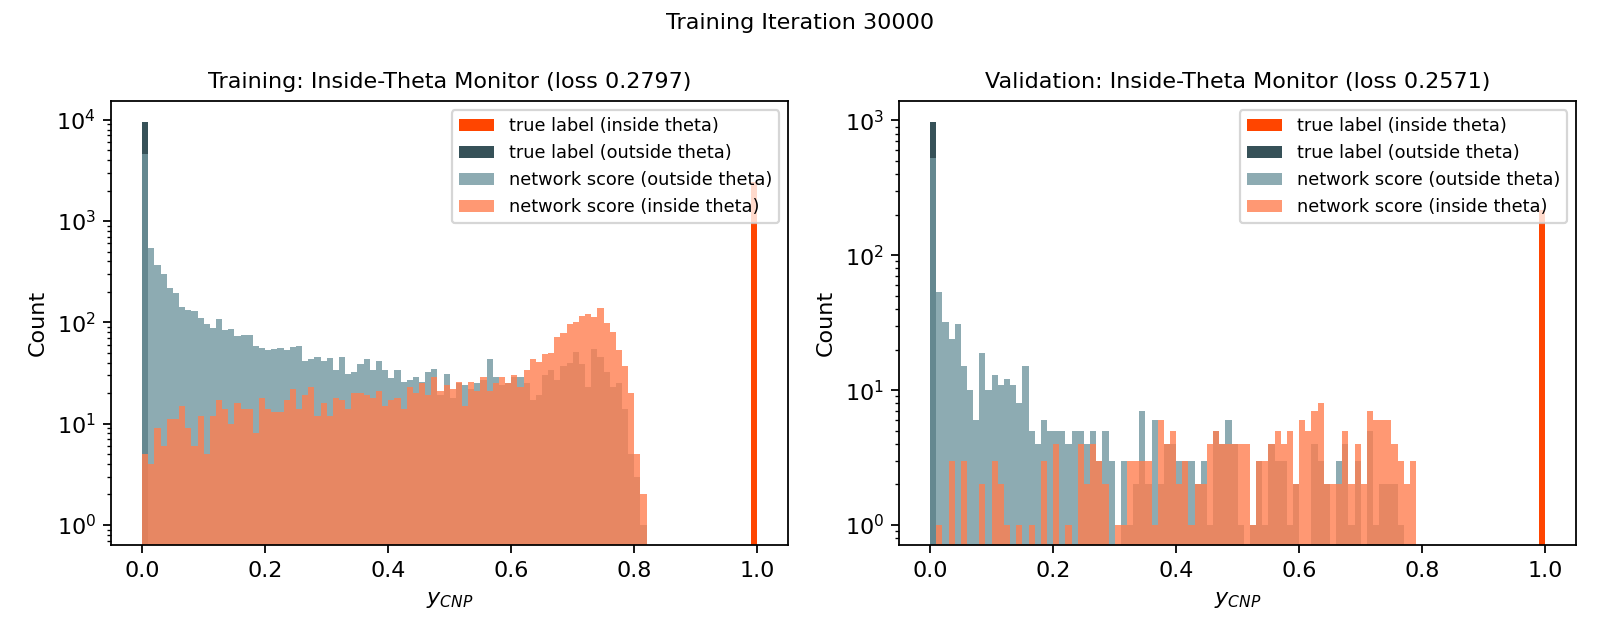

Epoch 7/15 | step=34999 | epoch_steps=5000 | train_bce=0.29174 | val_bce=0.27315
2026-06-08 07:22:33 Iteration: 7/35000, train BCE: 0.2784, val BCE: 0.2847


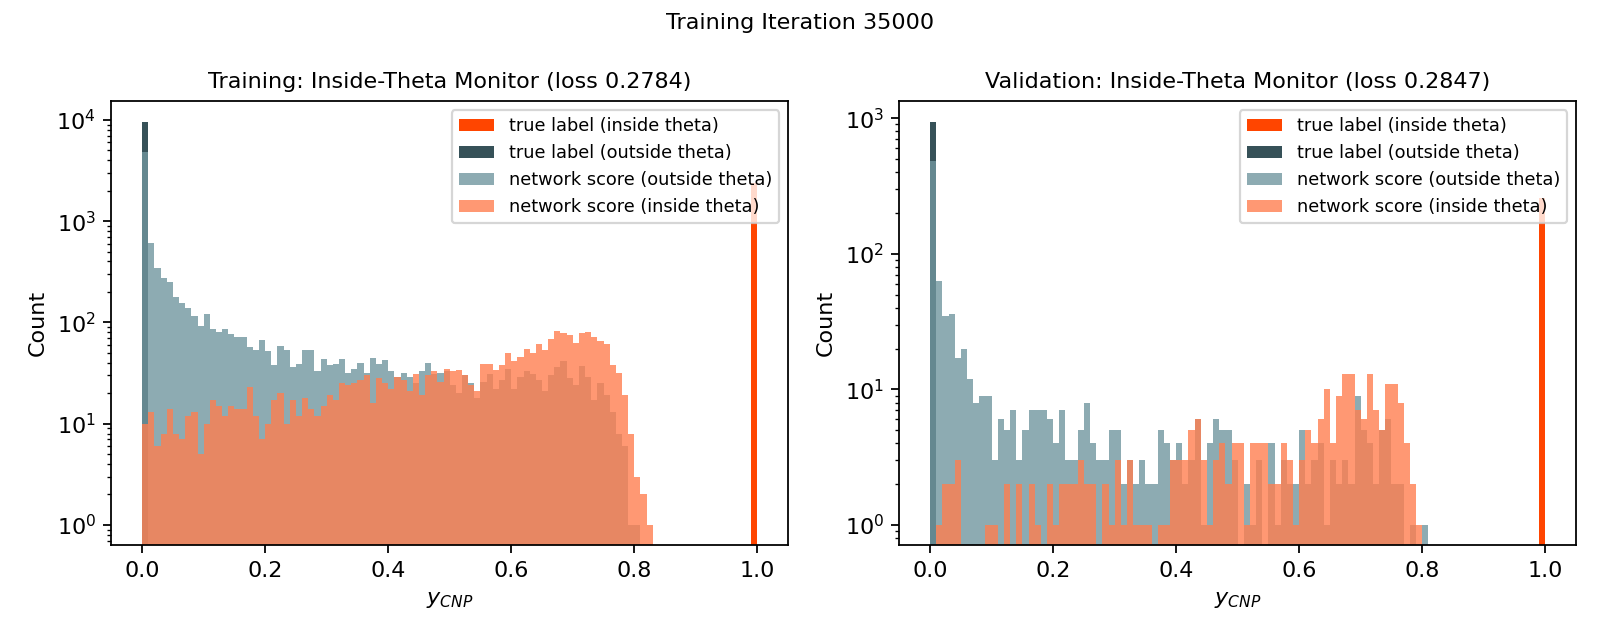

Epoch 8/15 | step=39999 | epoch_steps=5000 | train_bce=0.28654 | val_bce=0.28800
2026-06-08 07:22:58 Iteration: 8/40000, train BCE: 0.2848, val BCE: 0.2953


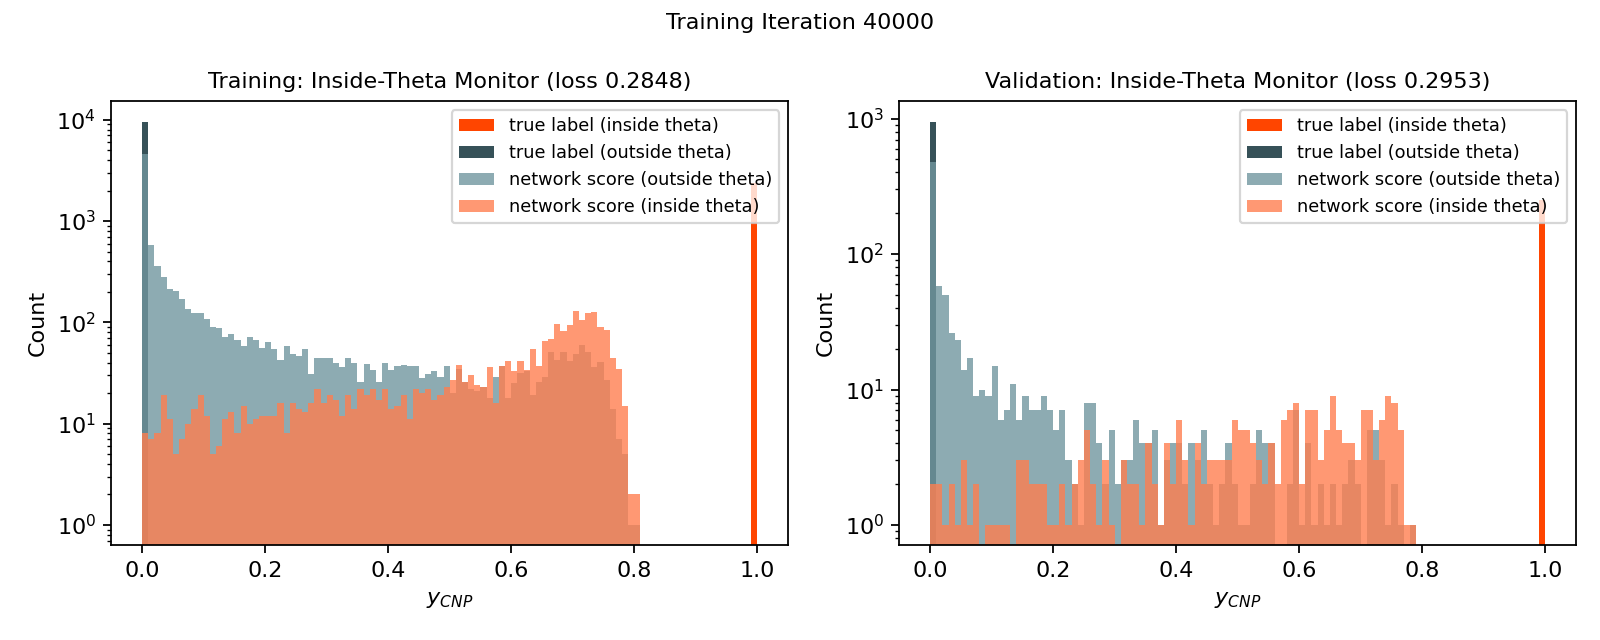

Epoch 9/15 | step=44999 | epoch_steps=5000 | train_bce=0.28836 | val_bce=0.30779
2026-06-08 07:23:25 Iteration: 9/45000, train BCE: 0.2924, val BCE: 0.2854


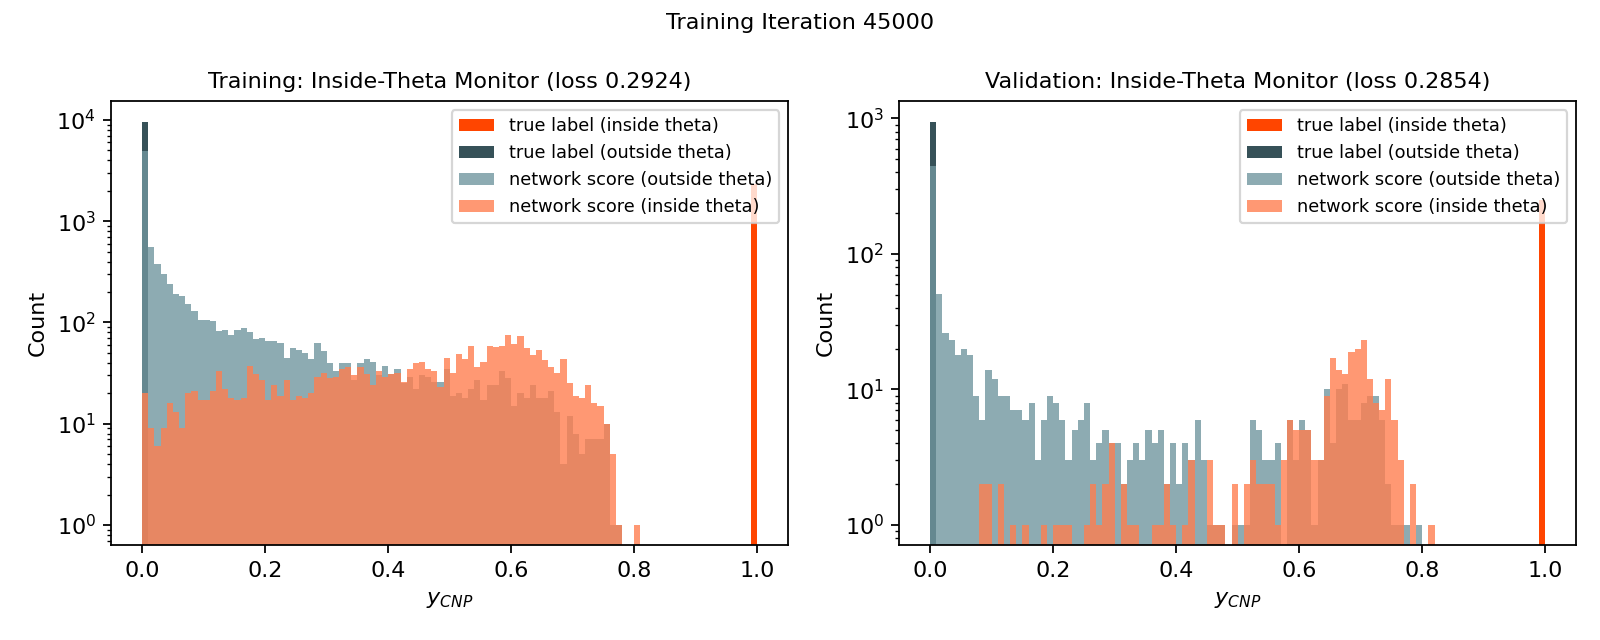

Epoch 10/15 | step=49999 | epoch_steps=5000 | train_bce=0.28543 | val_bce=0.29606
2026-06-08 07:23:51 Iteration: 10/50000, train BCE: 0.2755, val BCE: 0.2718


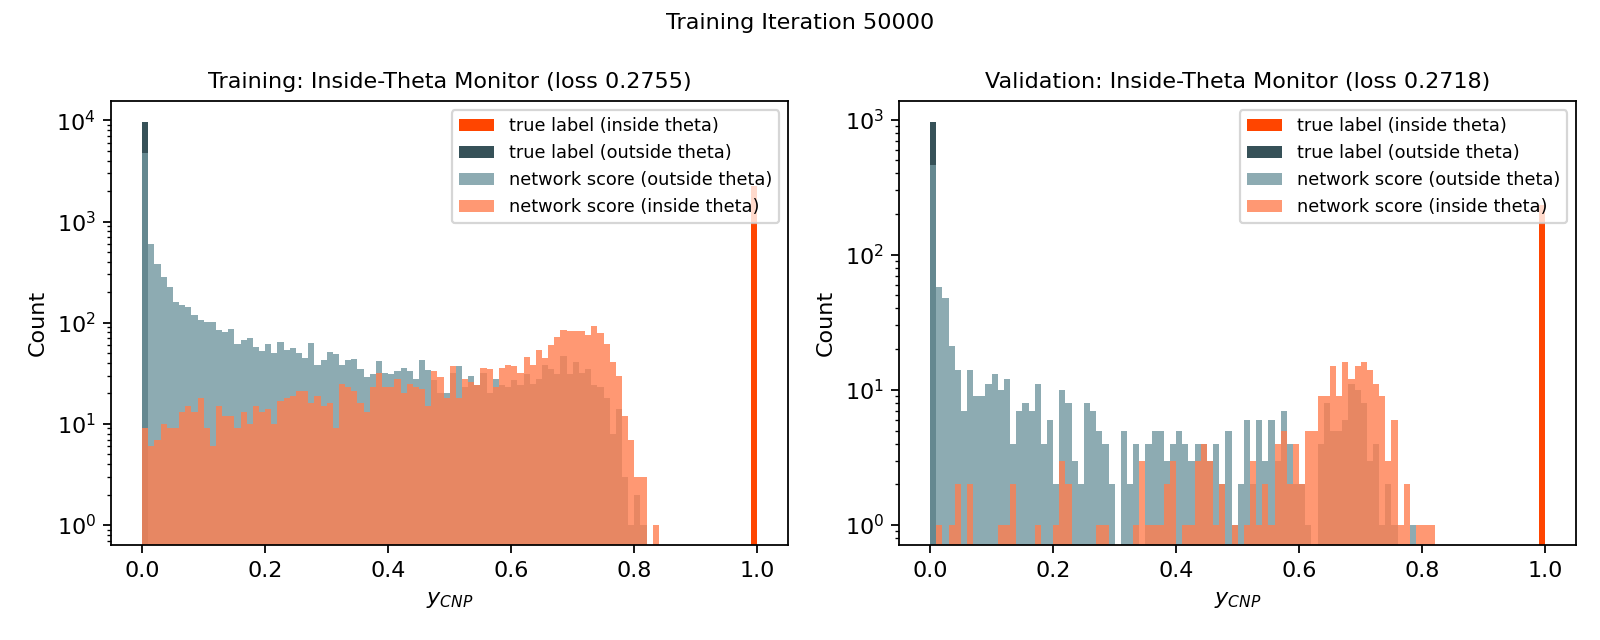

Epoch 11/15 | step=54999 | epoch_steps=5000 | train_bce=0.28107 | val_bce=0.27583
2026-06-08 07:24:18 Iteration: 11/55000, train BCE: 0.2794, val BCE: 0.2658


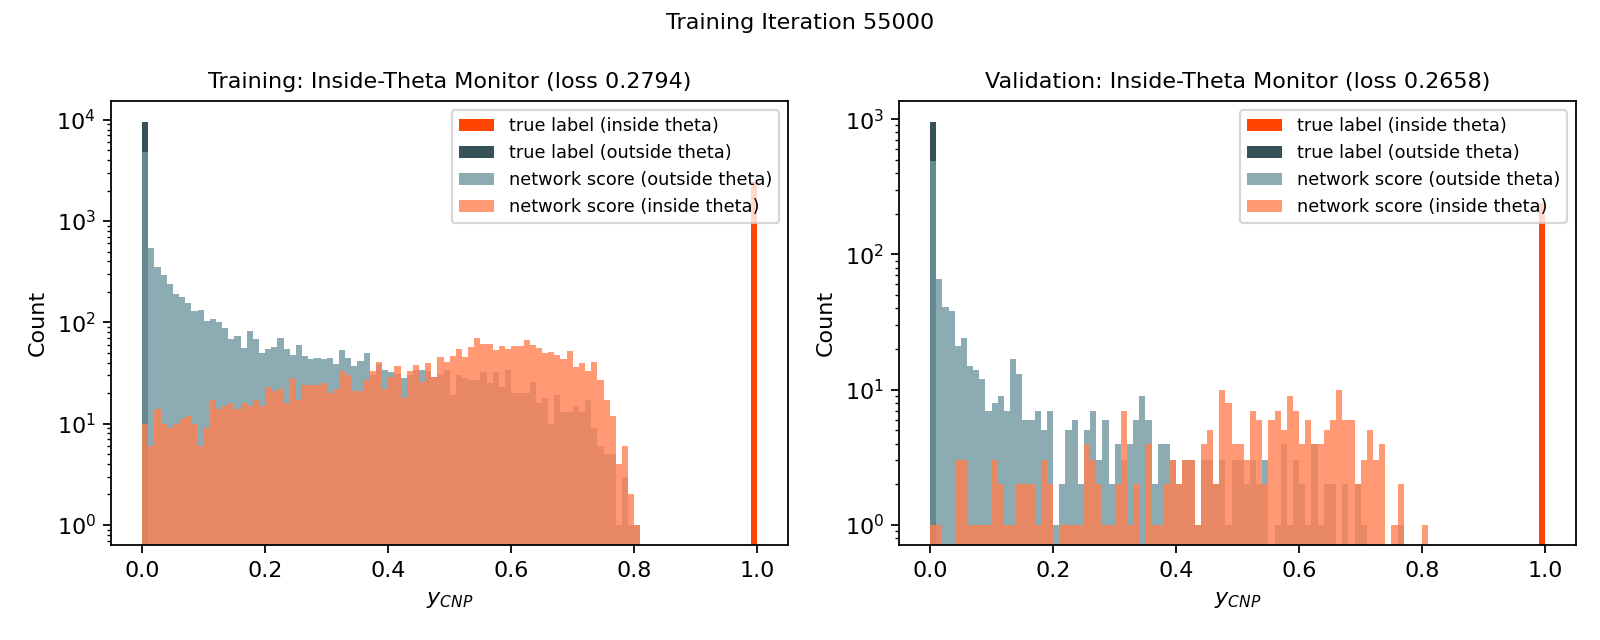

Epoch 12/15 | step=59999 | epoch_steps=5000 | train_bce=0.28887 | val_bce=0.30125
2026-06-08 07:24:45 Iteration: 12/60000, train BCE: 0.2834, val BCE: 0.2954


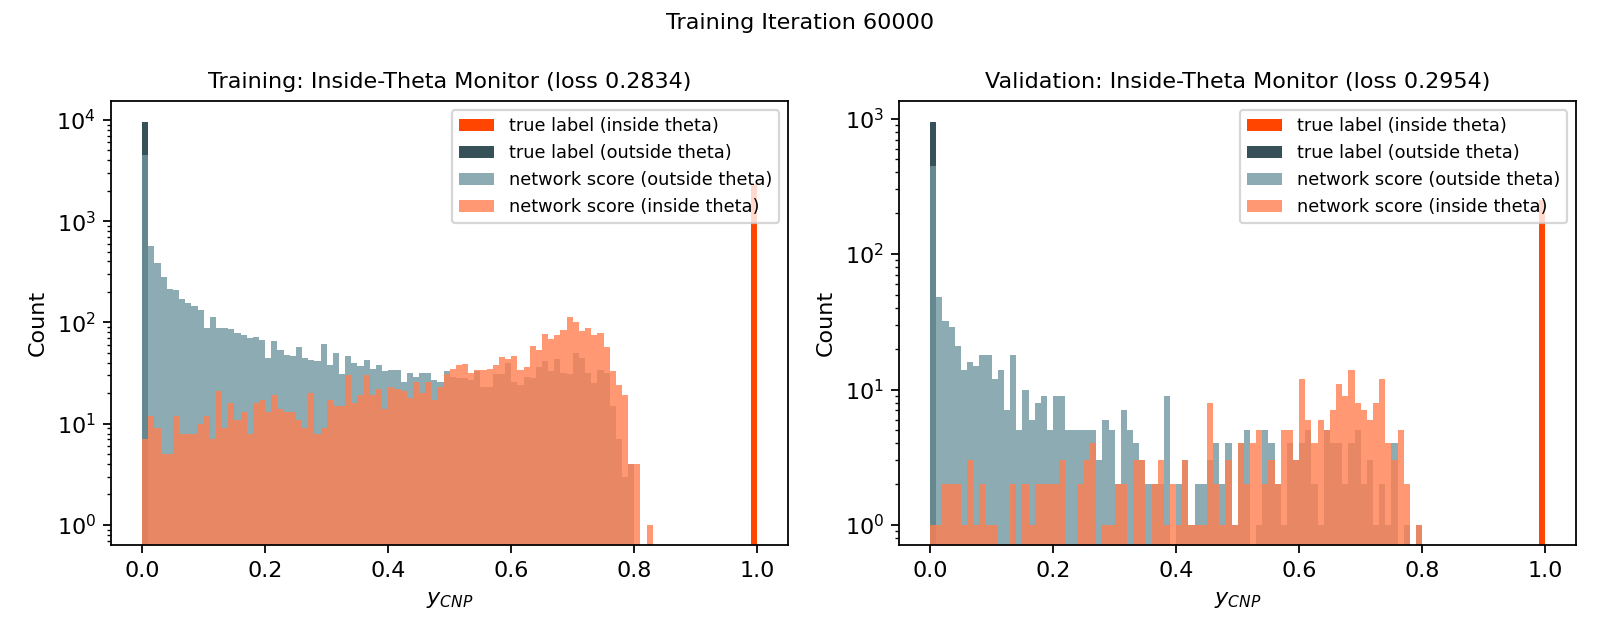

Epoch 13/15 | step=64999 | epoch_steps=5000 | train_bce=0.28104 | val_bce=0.29591
2026-06-08 07:25:10 Iteration: 13/65000, train BCE: 0.2909, val BCE: 0.2931


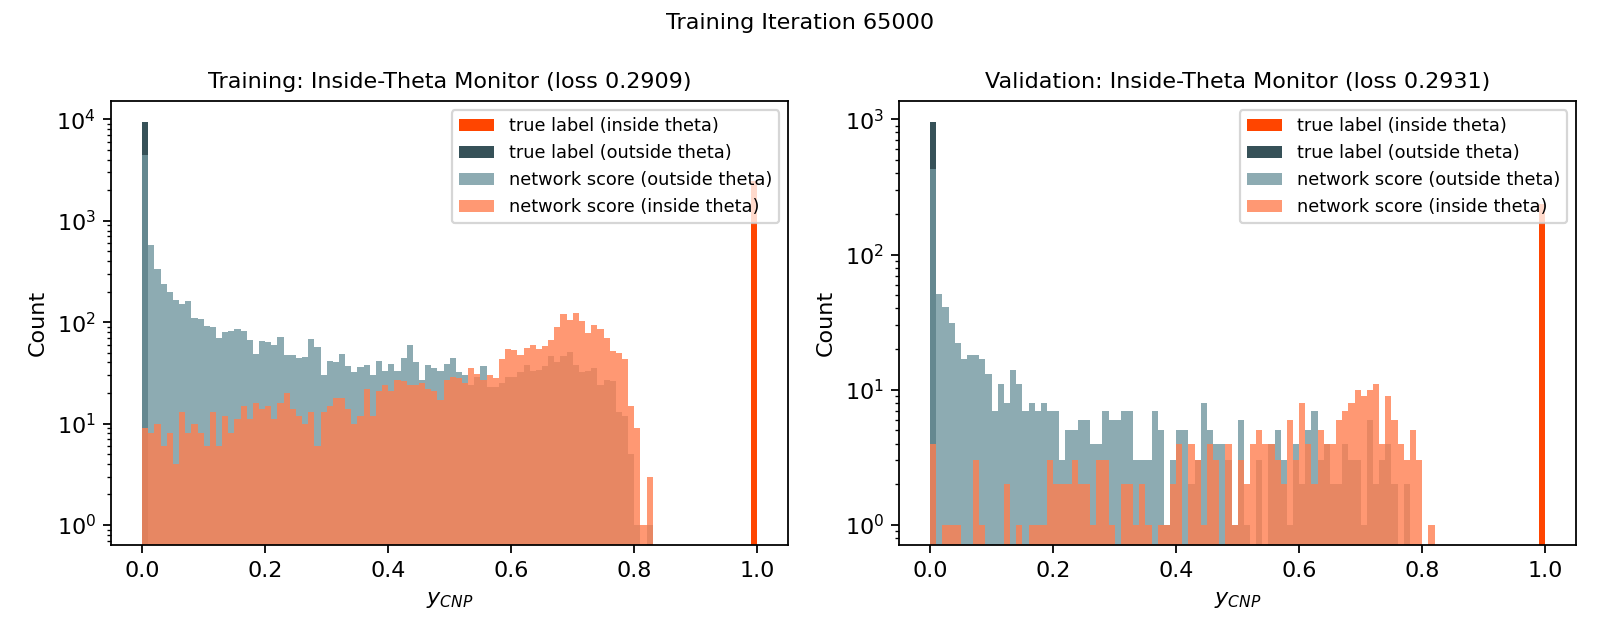

Epoch 14/15 | step=69999 | epoch_steps=5000 | train_bce=0.27884 | val_bce=0.35155
2026-06-08 07:25:37 Iteration: 14/70000, train BCE: 0.2866, val BCE: 0.2793


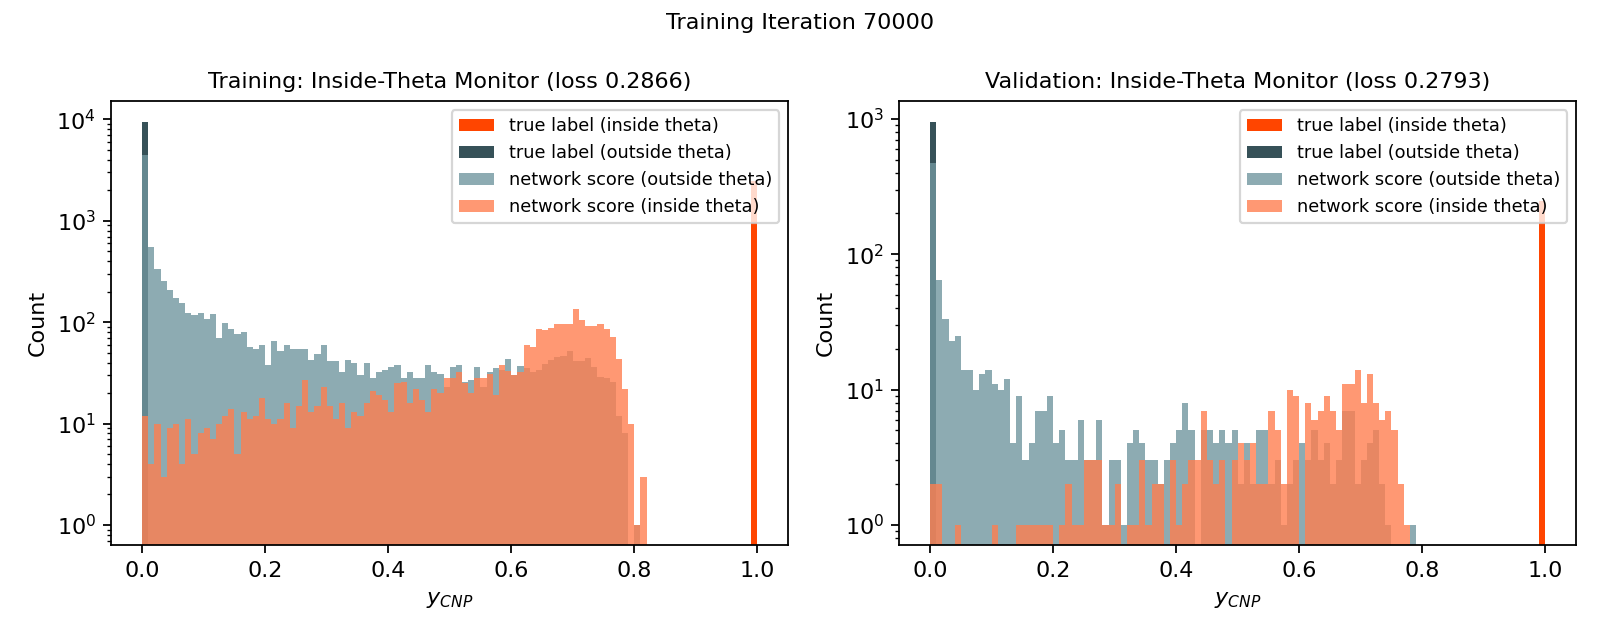

Epoch 15/15 | step=74999 | epoch_steps=5000 | train_bce=0.28114 | val_bce=0.28364


,artifact,path
0,model_path,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
1,history_csv,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
2,history_plot,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
3,sample_plot,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...


In [5]:
train_result = train_cnp(
    runtime,
    steps_per_epoch=STEPS_PER_EPOCH,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    repr_dim=REPR_DIM,
    hidden=HIDDEN,
    dropout=DROPOUT,
    monitor_every=MONITOR_EVERY,
    show_monitor_plots=True,
)

pd.DataFrame({
    "artifact": ["model_path", "history_csv", "history_plot", "sample_plot"],
    "path": [
        str(train_result.model_path),
        str(train_result.history_csv),
        str(train_result.history_plot),
        str(train_result.sample_plot),
    ],
})


## 5. Predict On Training LF/HF And Validation HF


In [6]:
train_prediction = predict_cnp(
    runtime,
    model_path=train_result.model_path,
    mc_samples=MC_SAMPLES,
    chunk_size=CHUNK_SIZE,
    output_suffix="train"
)

validation_prediction = predict_cnp(
    validation_runtime,
    model_path=train_result.model_path,
    mc_samples=MC_SAMPLES,
    chunk_size=CHUNK_SIZE,
    output_suffix="validation"
)

pd.DataFrame({
    "artifact": [
        "train_all",
        "train_best",
        "train_mfgp",
        "validation_all",
        "validation_best",
        "validation_mfgp",
    ],
    "path": [
        str(train_prediction.all_path),
        str(train_prediction.best_path),
        str(train_prediction.mfgp_path),
        str(validation_prediction.all_path),
        str(validation_prediction.best_path),
        str(validation_prediction.mfgp_path),
    ],
})



Starting CNP prediction
MFGP CSV:       /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_train_15epochs.csv
All-shell CSV:  /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_train_15epochs_all_shells.csv
Best-shell CSV: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_train_15epochs_best_shell.csv


TRAIN-LF:   0%|          | 0/53 [00:00<?, ?block/s]

TRAIN-HF:   0%|          | 0/21 [00:00<?, ?block/s]

Saved MFGP compatable CNP CSV: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_train_15epochs.csv
Saved all event-shell probabilities: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_train_15epochs_all_shells.csv
Saved best shell per event: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_train_15epochs_best_shell.csv

Starting CNP prediction
MFGP CSV:       /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_validation_15epochs.csv
All-shell CSV:  /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_validation_15epochs_all_shells.csv
Best-shell CSV: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_validation_15epochs_best_shell.csv


VAL-HF:   0%|          | 0/21 [00:00<?, ?block/s]

Saved MFGP compatable CNP CSV: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_validation_15epochs.csv
Saved all event-shell probabilities: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_validation_15epochs_all_shells.csv
Saved best shell per event: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_validation_15epochs_best_shell.csv


,artifact,path
0,train_all,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
1,train_best,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
2,train_mfgp,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
3,validation_all,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
4,validation_best,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
5,validation_mfgp,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...


## 6. Inspect CNP Outputs


In [7]:
cnp_train_csv = train_prediction.mfgp_path
cnp_val_csv = validation_prediction.mfgp_path

train_df = pd.read_csv(cnp_train_csv)
validation_df = pd.read_csv(cnp_val_csv)

display(train_df.head())
display(validation_df.head())

for path in [
    train_result.history_plot,
    train_result.sample_plot,
    train_prediction.heatmap_path,
    train_prediction.error_heatmap_path,
    validation_prediction.heatmap_path,
    validation_prediction.error_heatmap_path,
]:
    print(path)
    if Path(path).exists():
        try:
            display(Image(filename=str(path)))
        except Exception:
            pass


,iteration,fidelity,n_samples,R_shell,Z_shell,y_cnp,y_cnp_err,y_raw,log_prop,bce,source_file
0,0.0,0.0,1065116,323.16520,430.88693,4.263078e-08,0.096430,0.0,-0.000001,0.000001,aggregated_event_shell_predictions
1,0.0,0.0,1065116,407.16263,542.88354,9.654455e-08,0.098663,0.0,-0.000001,0.000001,aggregated_event_shell_predictions
2,0.0,0.0,1065116,466.08487,621.44650,2.549754e-07,0.101320,0.0,-0.000001,0.000001,aggregated_event_shell_predictions
3,0.0,0.0,1065116,512.99280,683.99036,4.896101e-07,0.104160,0.0,-0.000001,0.000001,aggregated_event_shell_predictions
4,0.0,0.0,1065116,552.60474,736.80630,8.863902e-07,0.107205,0.0,-0.000001,0.000001,aggregated_event_shell_predictions


,iteration,fidelity,n_samples,R_shell,Z_shell,y_cnp,y_cnp_err,y_raw,log_prop,bce,source_file
0,0.0,1.0,2130229,323.16520,430.88693,3.214463e-08,0.096310,0.0,-0.000001,0.000001,aggregated_event_shell_predictions
1,0.0,1.0,2130229,407.16263,542.88354,9.475278e-08,0.098671,0.0,-0.000001,0.000001,aggregated_event_shell_predictions
2,0.0,1.0,2130229,466.08487,621.44650,2.479824e-07,0.101371,0.0,-0.000001,0.000001,aggregated_event_shell_predictions
3,0.0,1.0,2130229,512.99280,683.99036,4.963848e-07,0.104157,0.0,-0.000001,0.000001,aggregated_event_shell_predictions
4,0.0,1.0,2130229,552.60474,736.80630,8.734901e-07,0.107318,0.0,-0.000001,0.000001,aggregated_event_shell_predictions


AttributeError: 'PredictResult' object has no attribute 'heatmap_path'

## 7. Fit The MF-GP Transform Suite


In [8]:
cnp_train_csv = train_prediction.mfgp_path
cnp_val_csv = validation_prediction.mfgp_path

mfgp_results = run_mfgp_transform_suite(
    config_path=CONFIG_PATH,
    cnp_csv=cnp_train_csv,
    validation_csv=cnp_val_csv,
    transforms=TARGET_TRANSFORMS,
    iteration=0,
    grid_points_per_axis=GRID_POINTS,
    random_state=RANDOM_STATE,
    predict_chunk_size=CHUNK_SIZE,
    verbose=True,
)

metrics_rows = []
for transform, result in mfgp_results.items():
    metrics_path = getattr(result, "metrics_json", None)
    if metrics_path and Path(metrics_path).exists():
        payload = json.loads(Path(metrics_path).read_text())
        metrics_rows.append({"transform": transform, **payload})
pd.DataFrame(metrics_rows) if metrics_rows else pd.DataFrame()



=== Running MF-GP target transform: linear ===
[stage] Loading runtime config...
[stage] Using CNP CSV: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_train_15epochs.csv
[stage] Loading LF/HF training rows...
[data] n_lf=100 n_hf=100 x_dim=2
[data] target_transform=linear use_log_lf=False use_log_hf=False eps=2.132e-08
[data] lf_cnp_noise=3.822e-01 hf_sim_noise=2.430e-02 alpha_lf=3.822e-01 alpha_hf=2.430e-10
[fit] Training LF GP...
[fit] Estimated rho=0.094299
[fit] Training HF discrepancy GP...
[fit] GP training complete.
[stage] Predicting on HF observations...
[progress] HF predict 100/100
[stage] Predicting on grid (3600 points)...
[progress] Grid predict 3600/3600
[stage] Loading validation CSV for extra plots: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_validation_15epochs.csv
[done] Generated theta-group uncertainty plots: 200
[done] MFGP complete | version=xlzd_equal_volume_shell_v1_minibatch | n_lf=100 n_hf=

,transform,rmse_hf,mae_hf,r2_hf,n_lf,n_hf,rho,target_transform,target_transform_eps
0,linear,2.844812e-10,7.362965e-11,1.000000,100,100,0.094299,linear,2.131539e-08
1,log_hf,4.006119e-01,1.211591e-01,0.958301,100,100,-5.076783,log_hf,2.131539e-08
2,log_lf,2.837373e-03,7.659566e-04,0.986361,100,100,-0.004161,log_lf,2.131539e-08
3,log_both,3.961966e-01,1.188058e-01,0.959215,100,100,1.592394,log_both,2.131539e-08


## 8. Display MF-GP Plots


=== Normal MF-GP ===
4-fold MF-GP mean/std: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_linear_mean_std_iter0.png


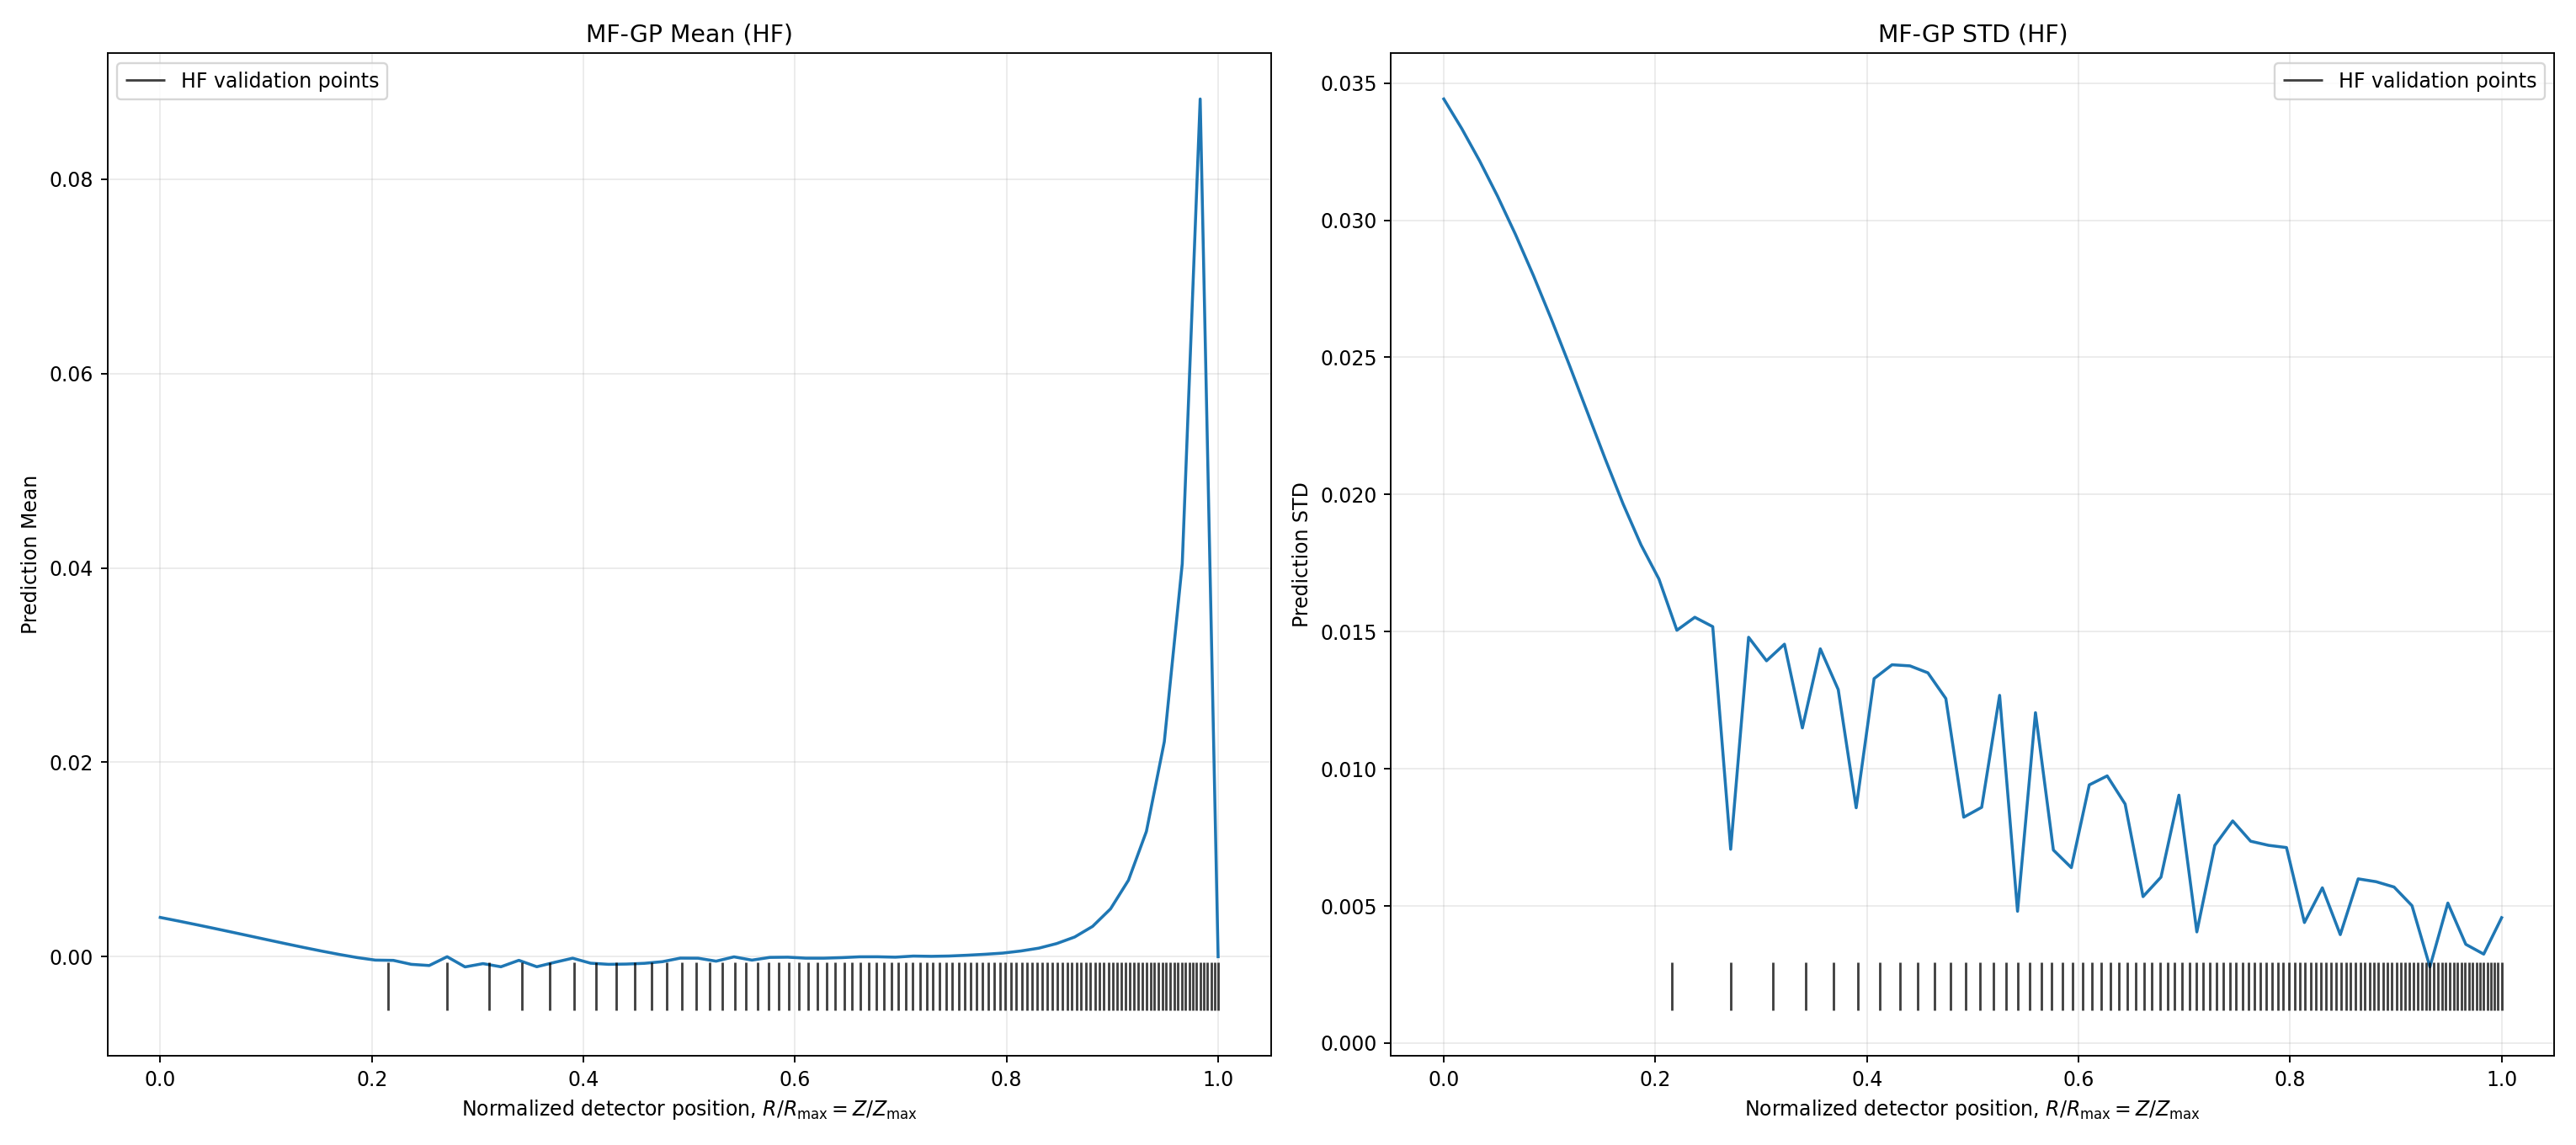

Interactive 3D mean/std HTML: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_linear_mean_std_3d_interactive_iter0.html
Validation 3-sigma: y with linear sigma: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_linear_validation_across_thetas_linear_iter0.png


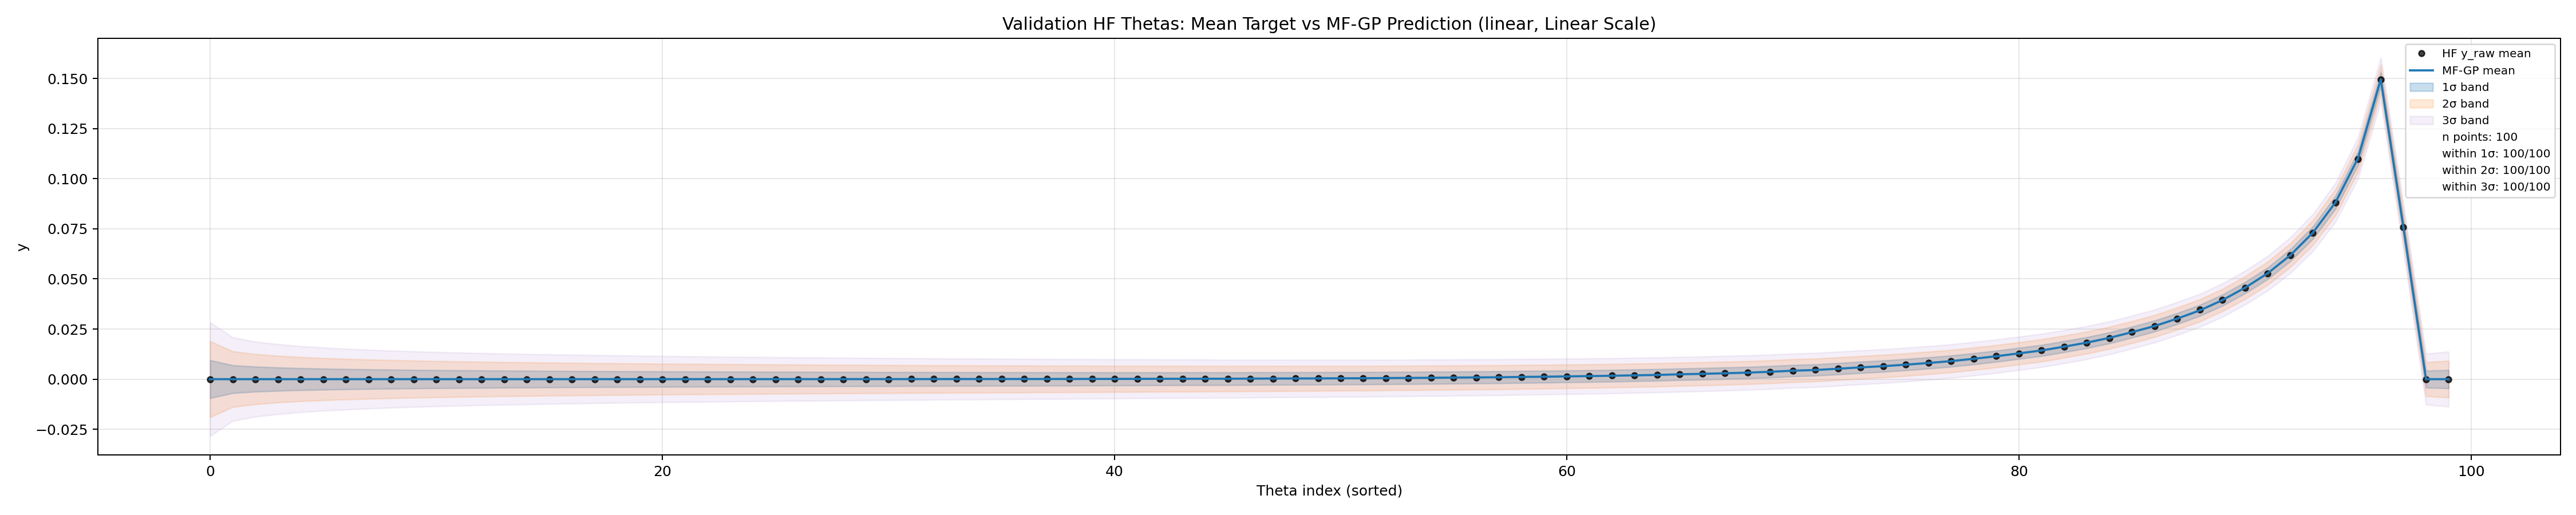

Validation 3-sigma: log10(y) with linear sigma: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_linear_validation_across_thetas_log_linear_sigma_iter0.png


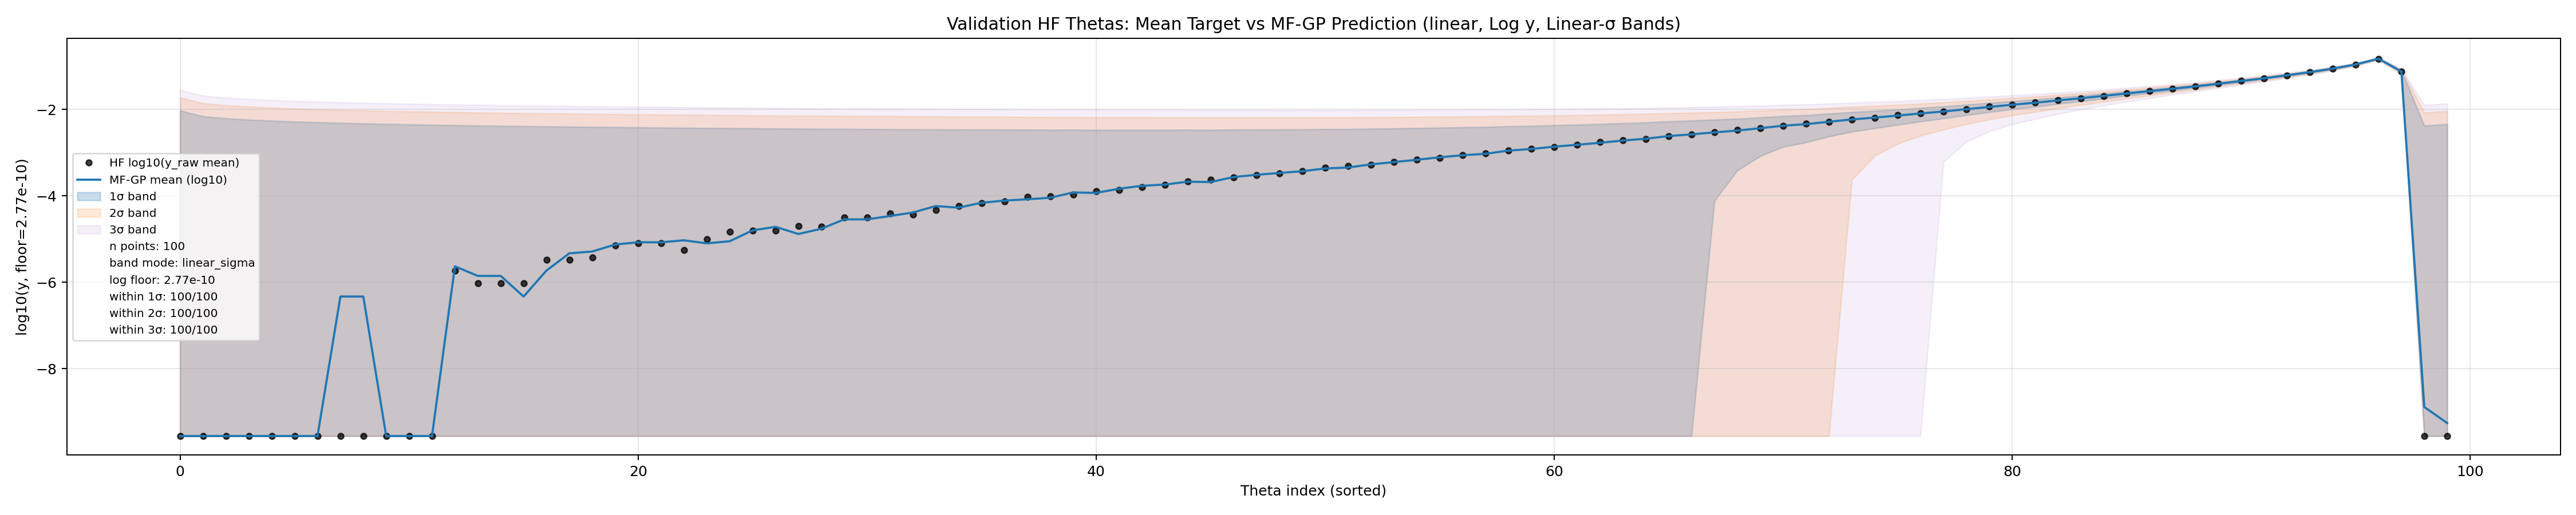

Validation parity: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_linear_validation_parity_linear_iter0.png


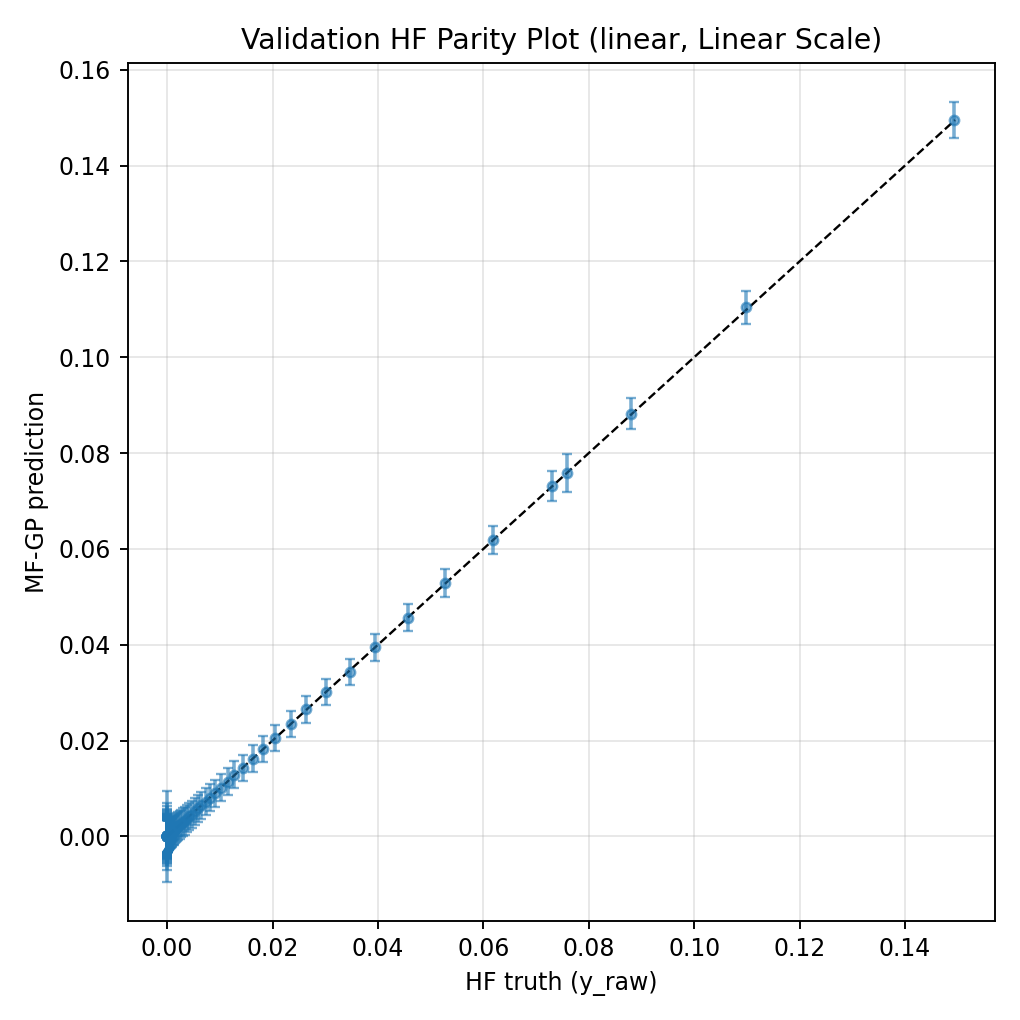

=== Log HF: emulate log10(y_raw) ===
4-fold MF-GP mean/std: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_hf_mean_std_iter0.png


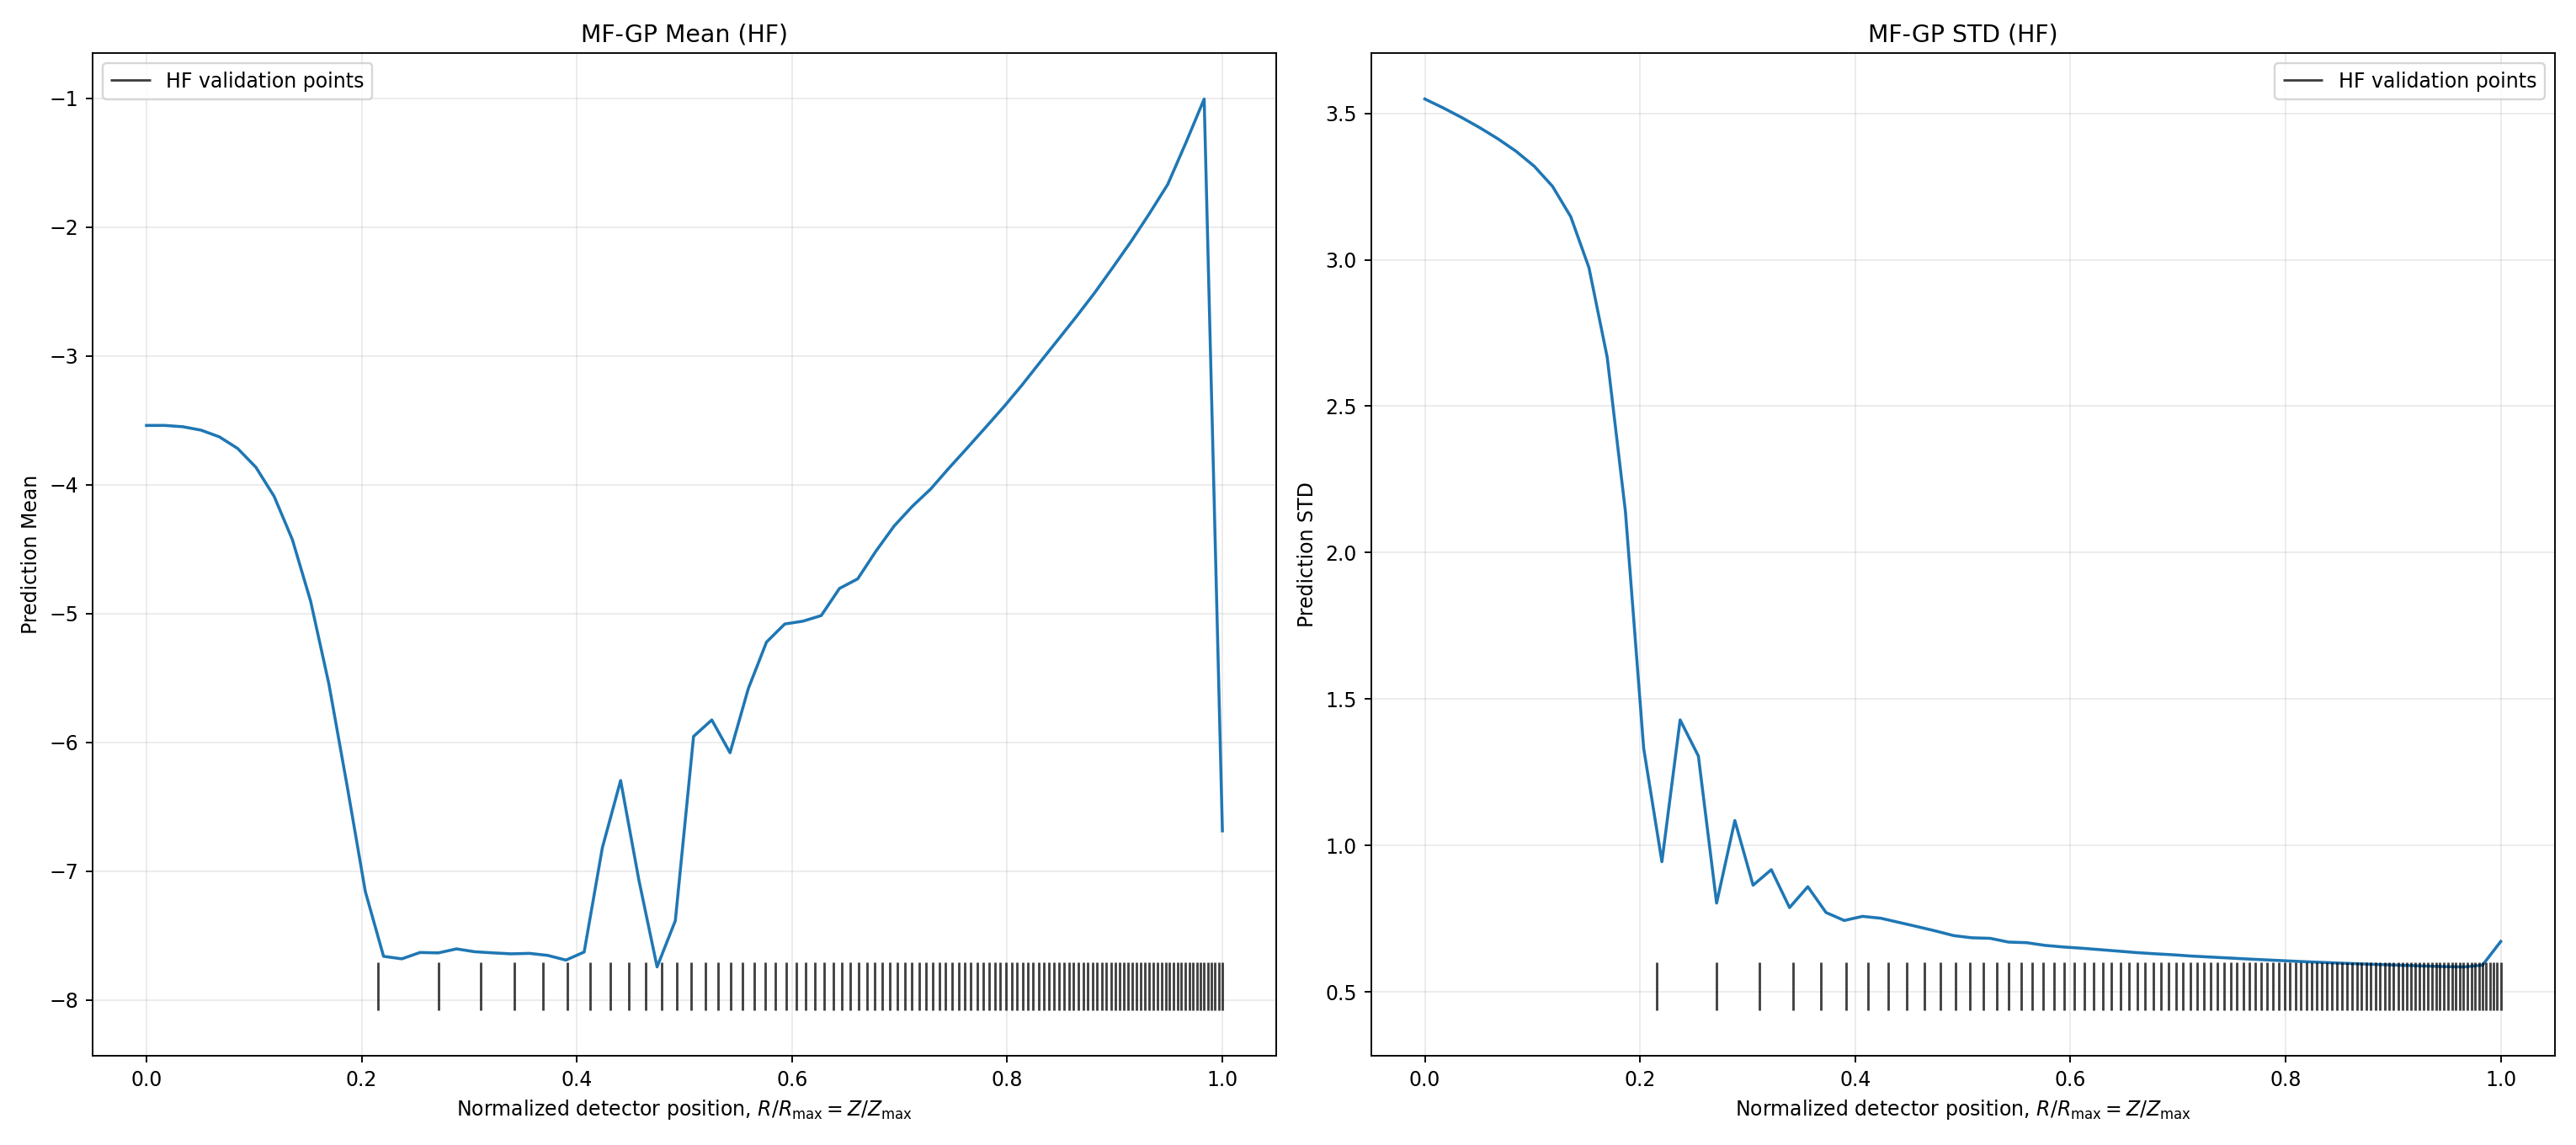

Interactive 3D mean/std HTML: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_hf_mean_std_3d_interactive_iter0.html
Validation 3-sigma: log10 target with linear sigma: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_hf_validation_across_thetas_linear_iter0.png


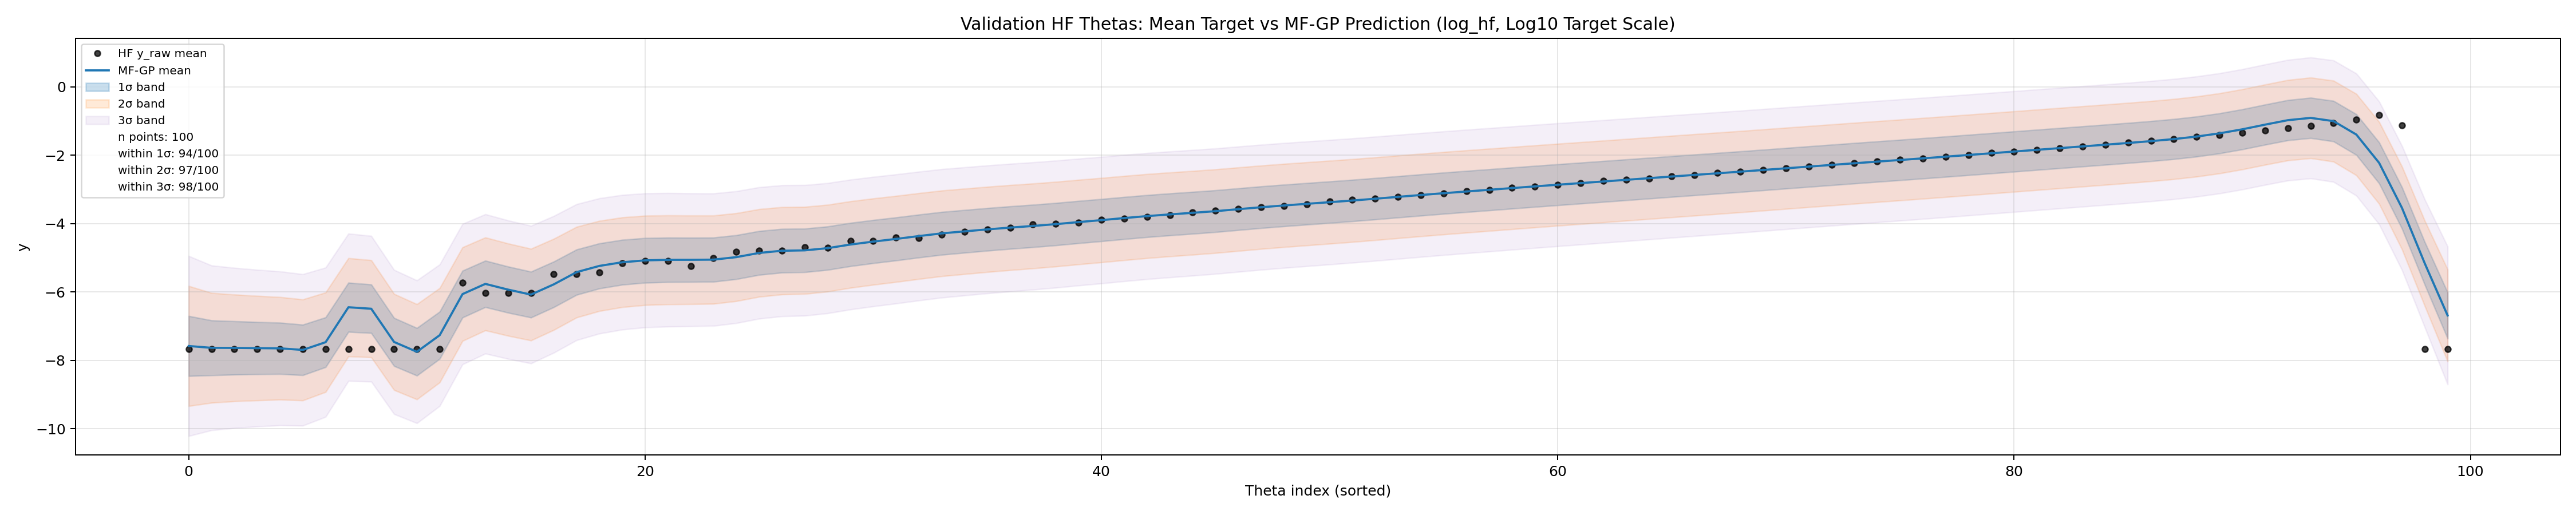

=== Log LF: use log10(y_cnp) ===
4-fold MF-GP mean/std: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_lf_mean_std_iter0.png


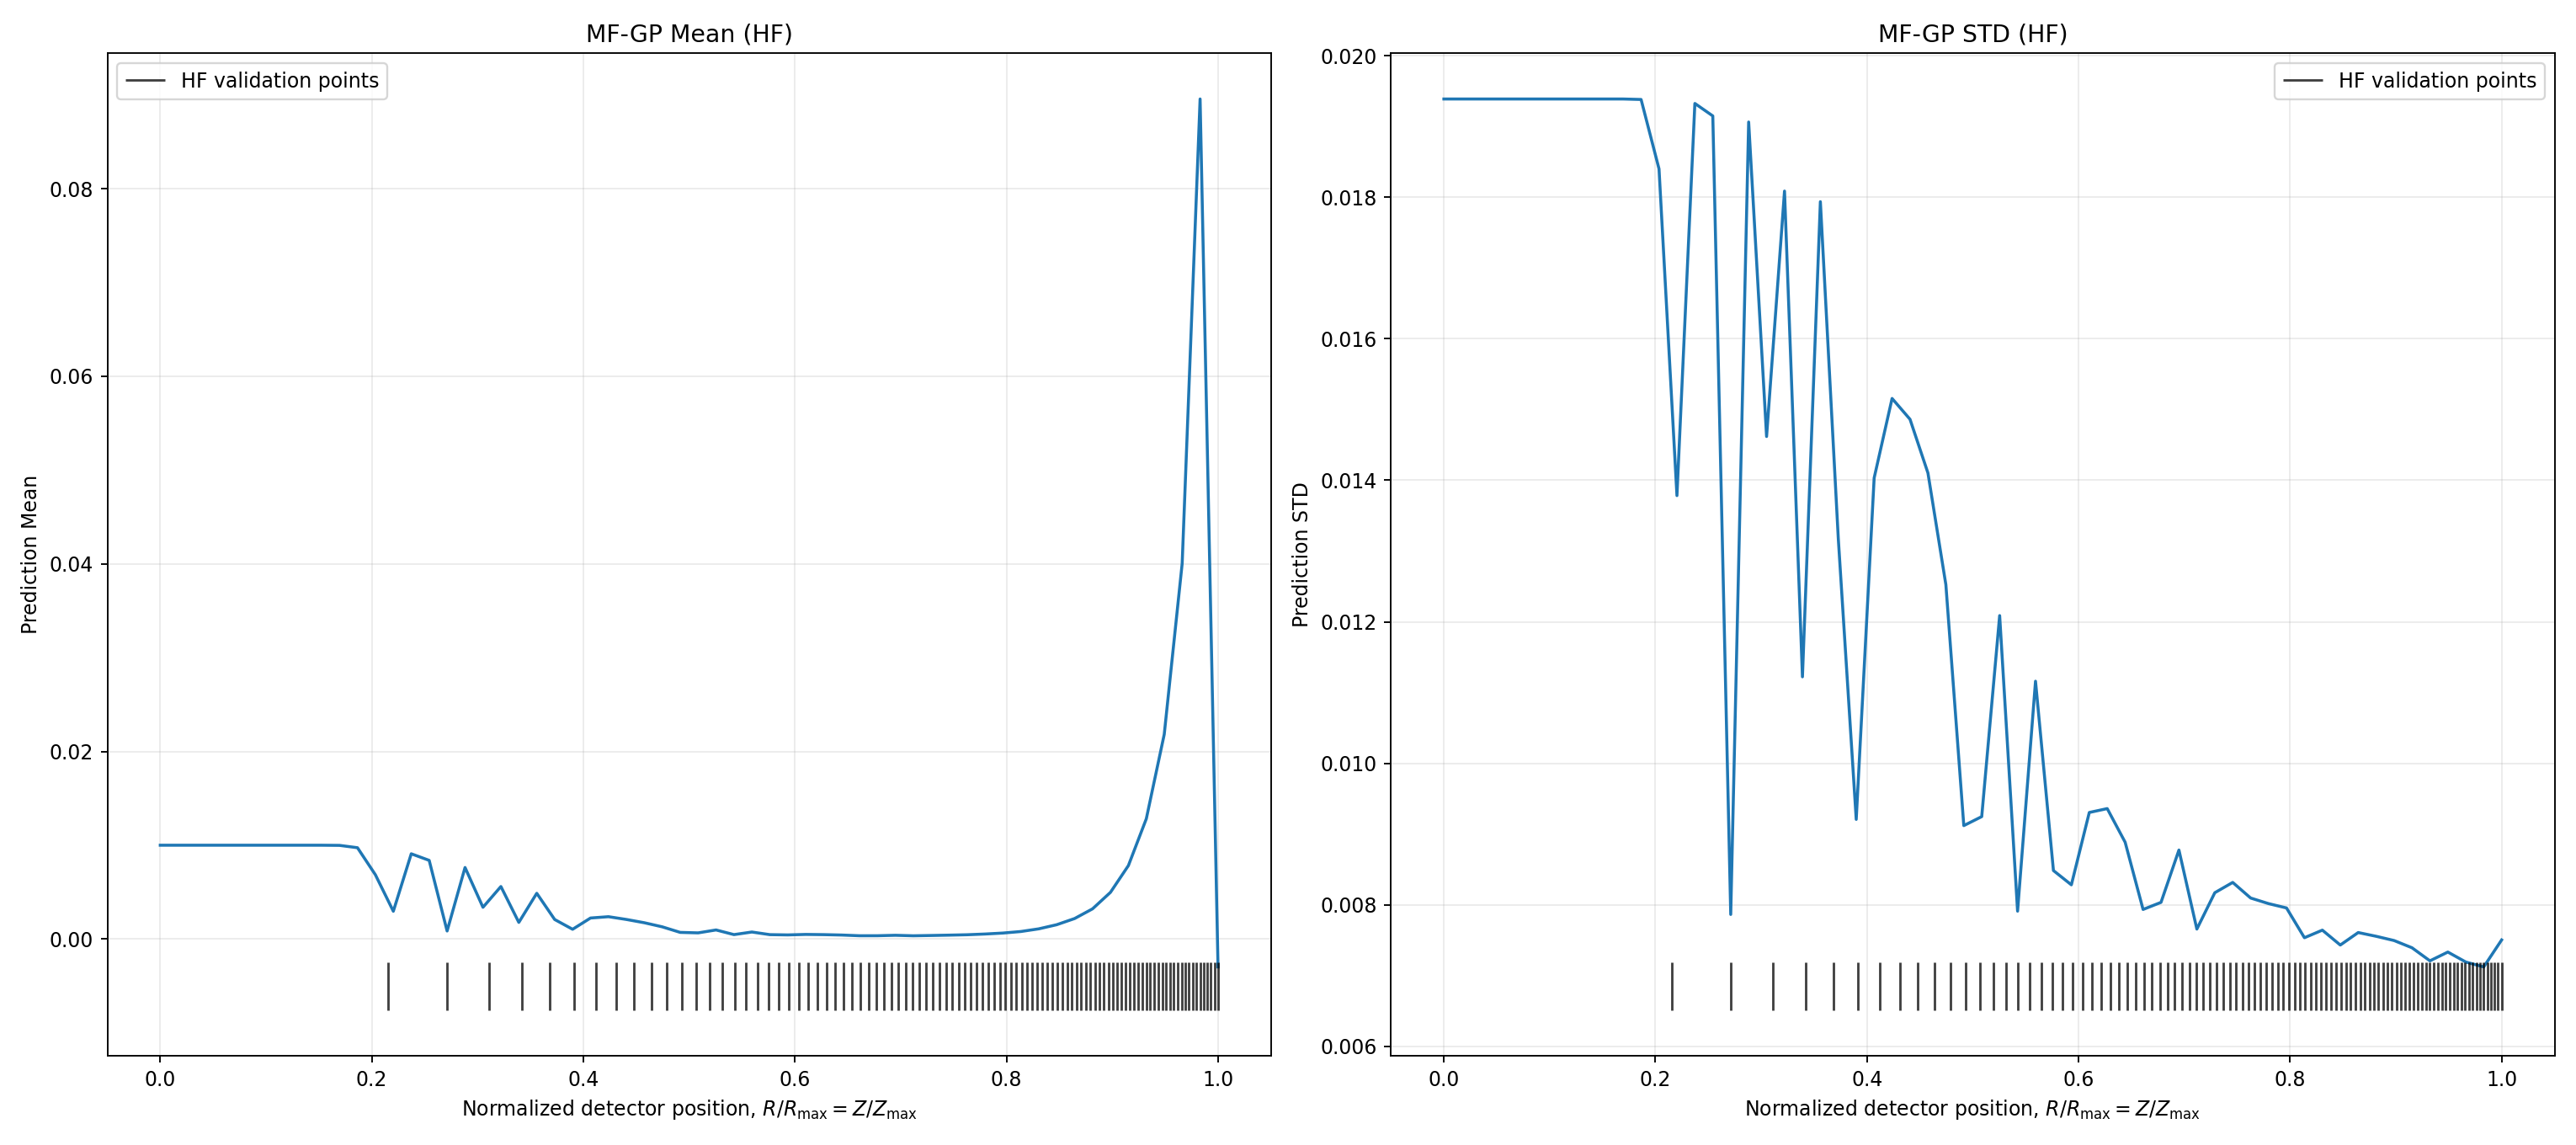

Interactive 3D mean/std HTML: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_lf_mean_std_3d_interactive_iter0.html
Validation 3-sigma: y with linear sigma: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_lf_validation_across_thetas_linear_iter0.png


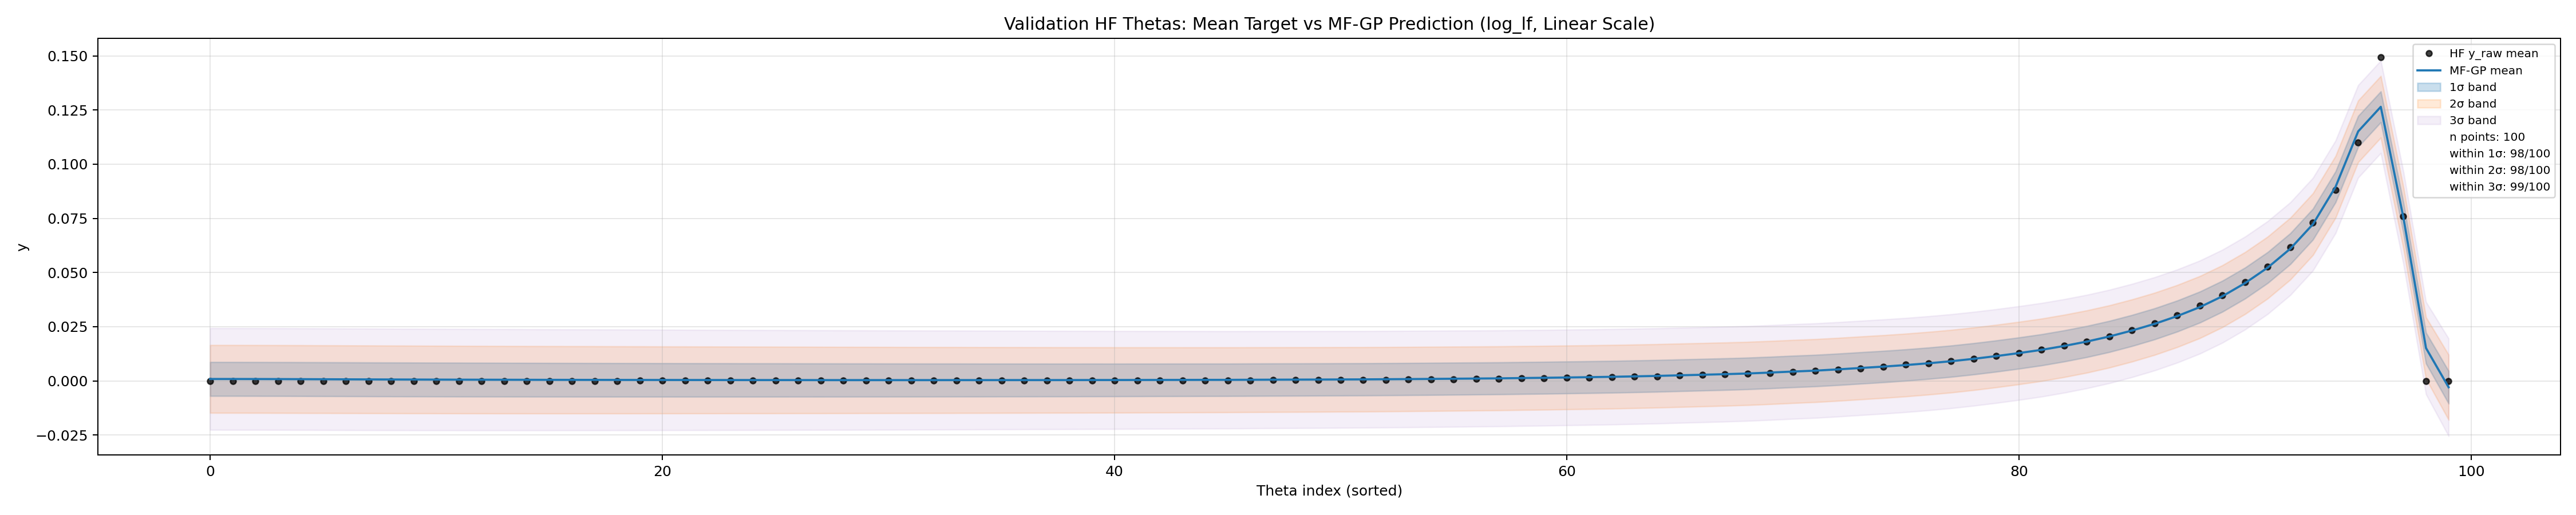

Validation 3-sigma: log10(y) with linear sigma: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_lf_validation_across_thetas_log_linear_sigma_iter0.png


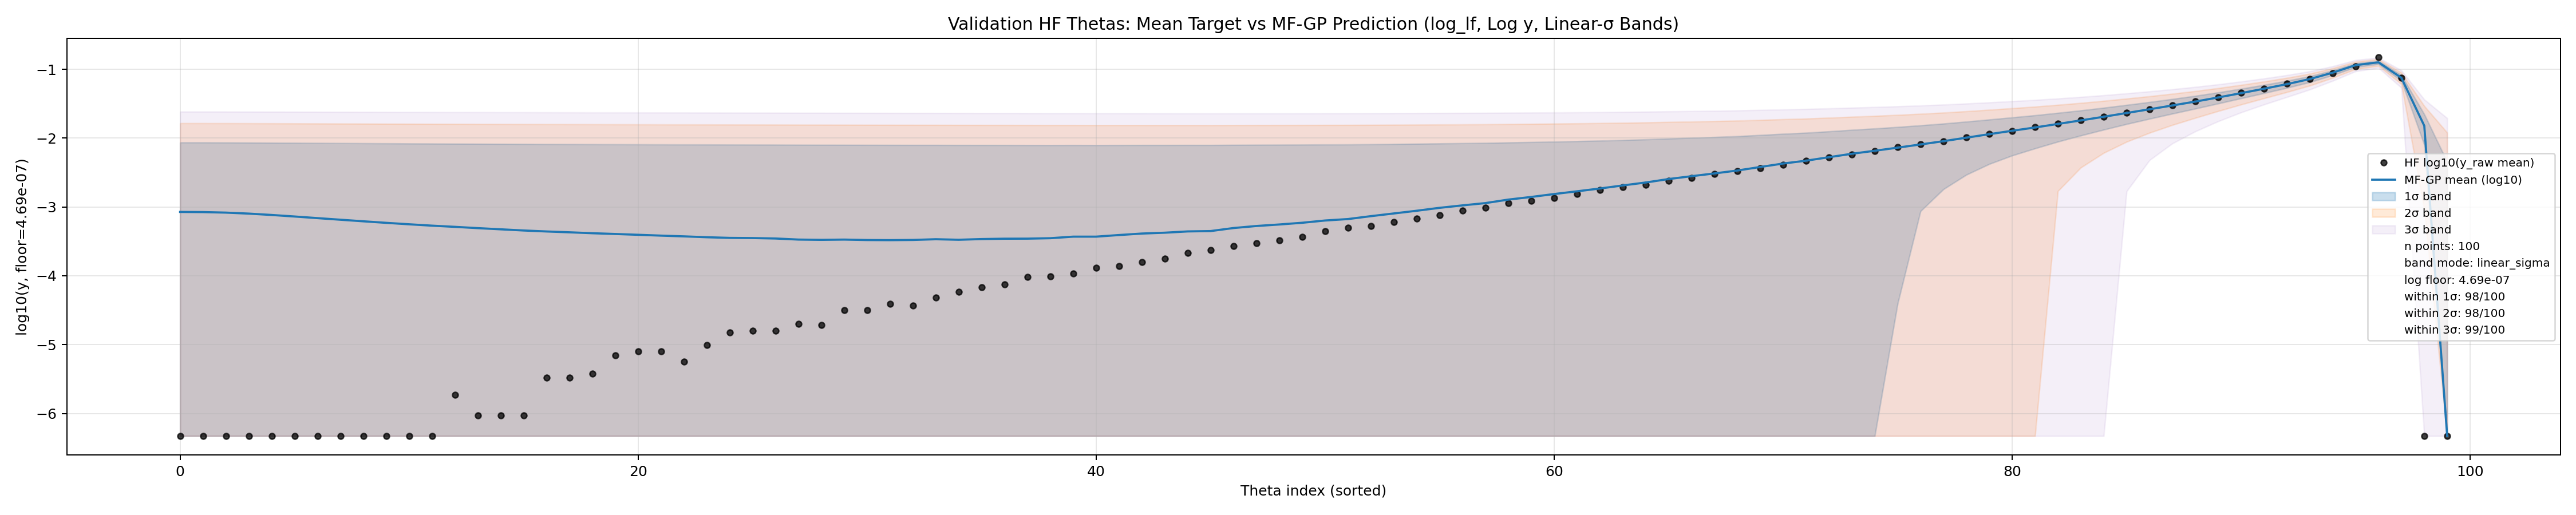

Validation parity: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_lf_validation_parity_linear_iter0.png


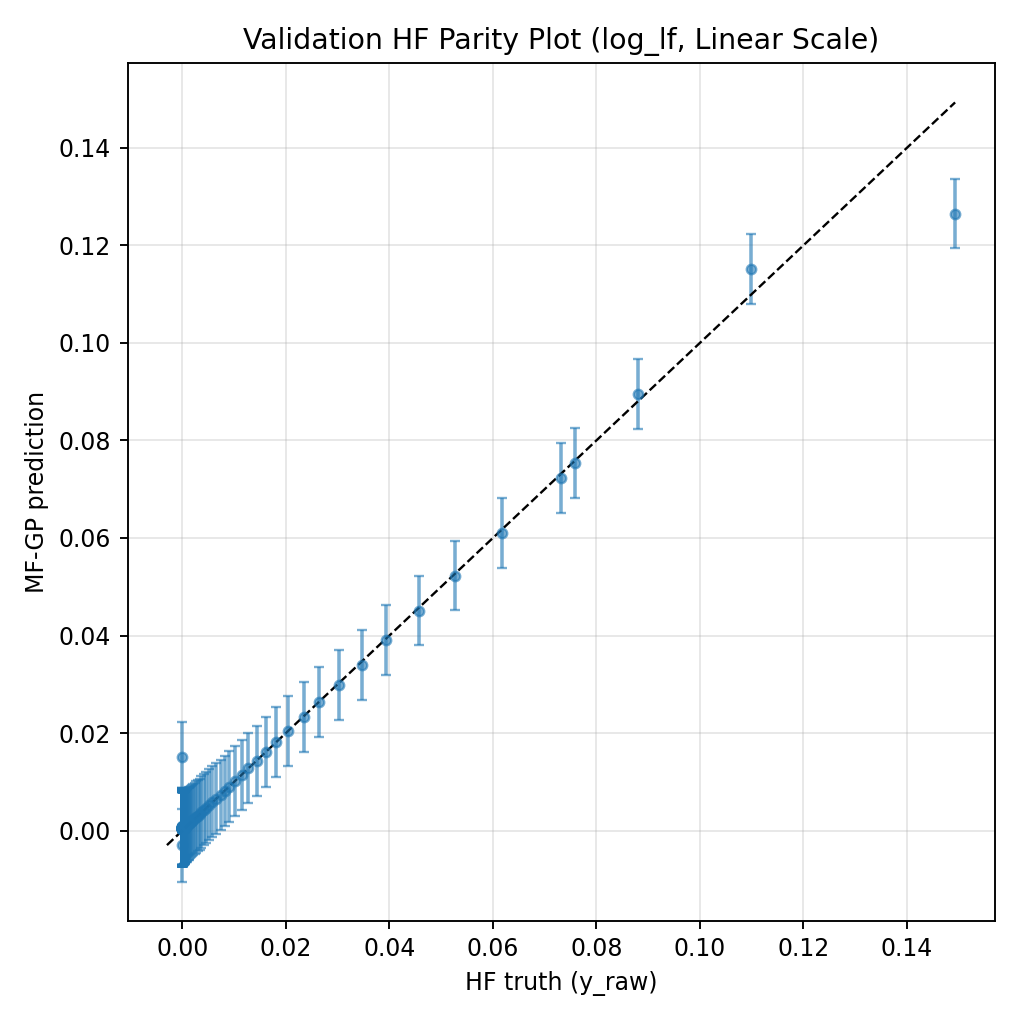

=== Log HF + Log LF: use log10(y_raw) and log10(y_cnp) ===
4-fold MF-GP mean/std: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_both_mean_std_iter0.png


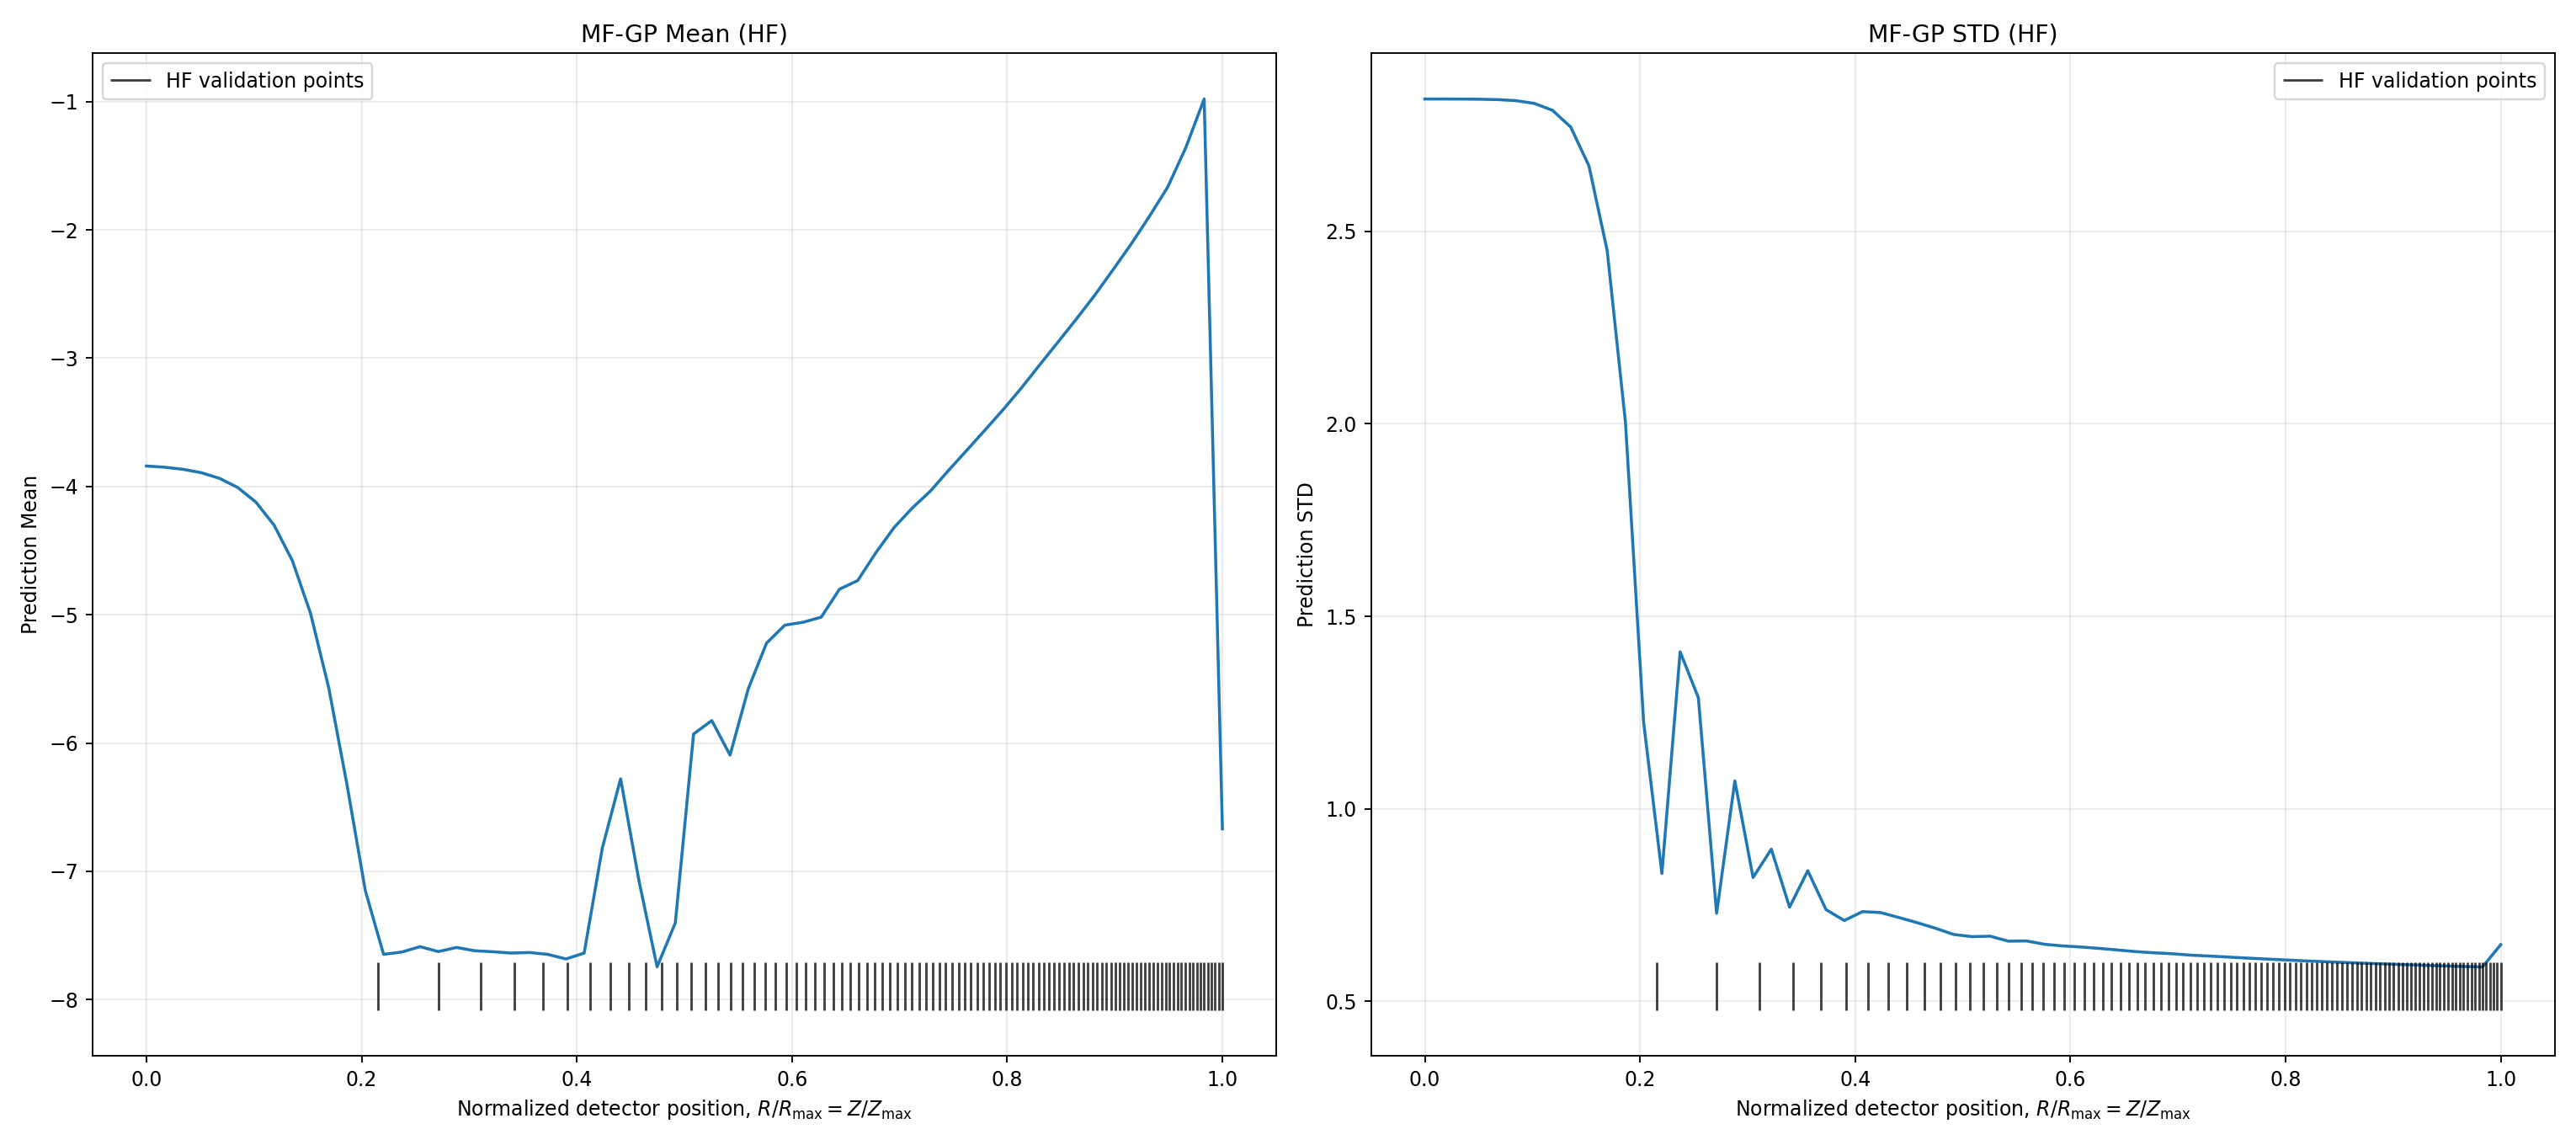

Interactive 3D mean/std HTML: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_both_mean_std_3d_interactive_iter0.html
Validation 3-sigma: log10 target with linear sigma: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_both_validation_across_thetas_linear_iter0.png


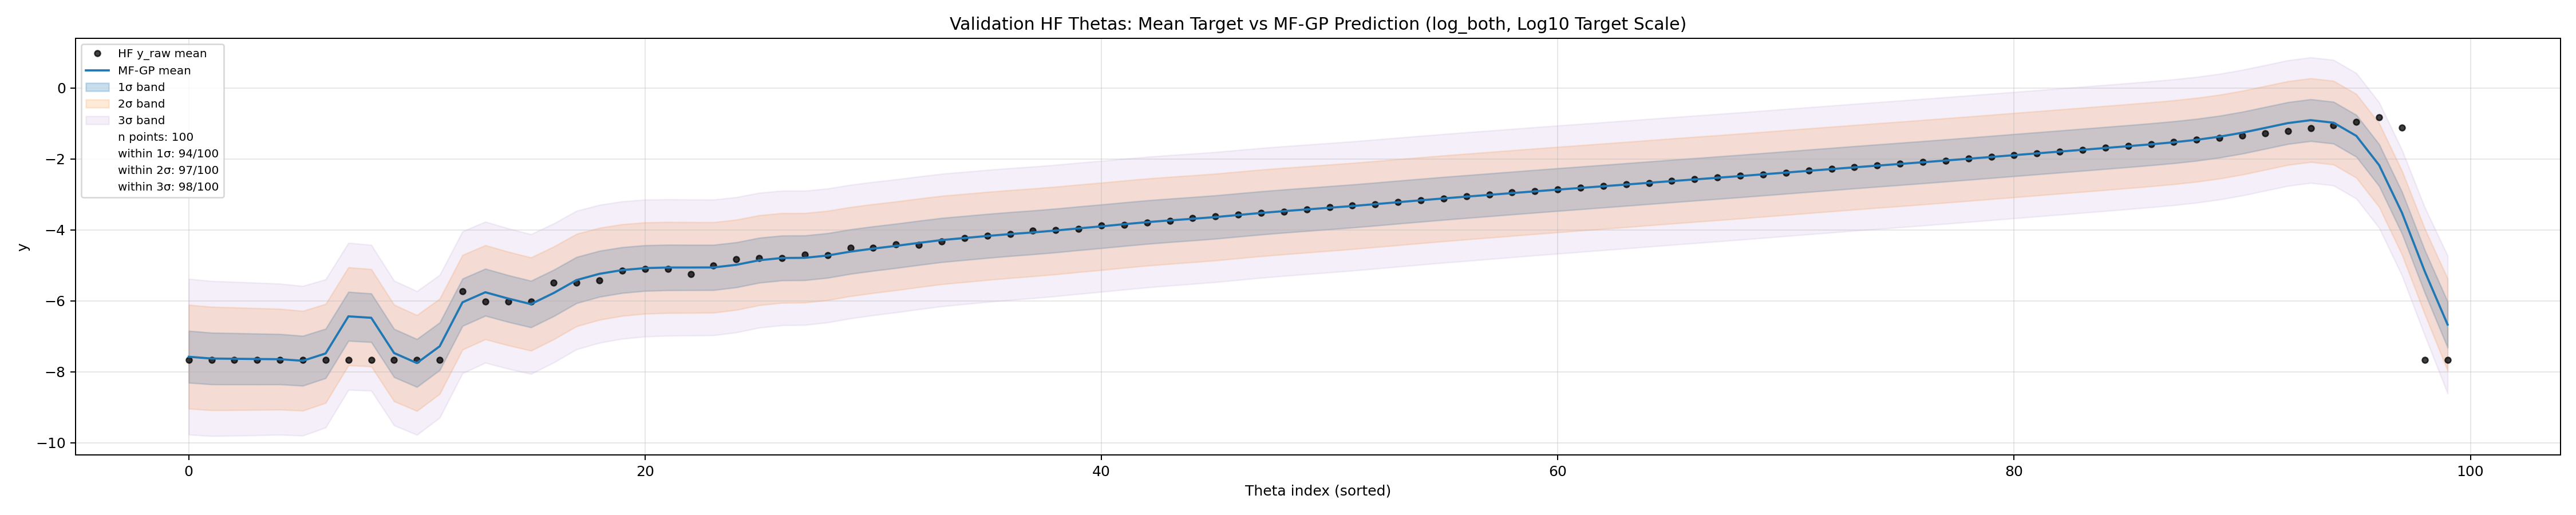

In [9]:
EXPERIMENT_TITLES = {
    "linear": "Normal MF-GP",
    "log_hf": "Log HF: emulate log10(y_raw)",
    "log_lf": "Log LF: use log10(y_cnp)",
    "log_both": "Log HF + Log LF: use log10(y_raw) and log10(y_cnp)",
}

PLOT_SELECTIONS = {
    "linear": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: y with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: log10(y) with linear sigma", "validation_across_theta_log_linear_sigma_plot"),
        ("Validation parity", "validation_parity_linear_plot"),
    ],
    "log_hf": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: log10 target with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: y with 10**(mu±sigma)", "validation_across_theta_log_plot"),
        ("Validation parity", "validation_parity_log_plot"),
    ],
    "log_lf": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: y with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: log10(y) with linear sigma", "validation_across_theta_log_linear_sigma_plot"),
        ("Validation parity", "validation_parity_linear_plot"),
    ],
    "log_both": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: log10 target with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: y with 10**(mu±sigma)", "validation_across_theta_log_plot"),
        ("Validation parity", "validation_parity_log_plot"),
    ],
}

def show_plot(result, label, key):
    value = getattr(result, key, None)
    if not value:
        return
    print(f"{label}: {value}")
    path = Path(value)
    if path.suffix.lower() == ".png" and path.exists():
        try:
            display(Image(filename=str(path)))
        except Exception:
            pass

for transform in TARGET_TRANSFORMS:
    result = mfgp_results.get(transform)
    if result is None:
        continue
    print(f"=== {EXPERIMENT_TITLES[transform]} ===")
    for label, key in PLOT_SELECTIONS[transform]:
        show_plot(result, label, key)
